# Auxiliary Scripts
- Install dependencies
- Import packages
- Load Checkpoint function

In [1]:
!pip install epanns-inference

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import random
import os
from epanns_inference import models
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
def load_lightning2pt(checkpoint_path, model, device="cpu", verbose=True, validate_updates=True):
    """
    Loads a PyTorch Lightning checkpoint's state_dict into a plain PyTorch model and optionally verifies parameter updates.

    :param checkpoint_path: Absolute Path to the Lightning checkpoint file (.ckpt).
    :param model: The plain PyTorch model instance to load the checkpoint into.
    :param device: Device to load the model onto ('cpu' or 'cuda').
    :param verbose: Whether to print detailed information about the loading process (default: True).
    :param validate_updates: Whether to validate which layers were updated during fine-tuning (default: True).
    :return: The plain PyTorch model with weights loaded from the checkpoint, and a list of updated layers (if validated).
    """
    # Step 1: Load the Lightning checkpoint
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    except FileNotFoundError:
        raise ValueError(f"Checkpoint file not found at: {checkpoint_path}")
    except Exception as e:
        raise ValueError(f"Failed to load checkpoint: {e}")

    # Step 2: Extract the Lightning state_dict
    if "state_dict" not in checkpoint:
        raise ValueError(f"Checkpoint does not contain a 'state_dict'. Keys found: {list(checkpoint.keys())}")

    lightning_state_dict = checkpoint["state_dict"]

    # Step 3: Generalize prefix removal
    stripped_state_dict = {}
    prefix = None

    for key in lightning_state_dict.keys():
        if "." in key:
            prefix = key.split(".")[0] + "."
            break

    if prefix:
        stripped_state_dict = {key.replace(prefix, ""): value for key, value in lightning_state_dict.items()}
        if verbose:
            print(f"Detected prefix '{prefix}'. Stripped from state_dict keys.")
    else:
        stripped_state_dict = lightning_state_dict
        if verbose:
            print("No prefix detected in state_dict keys.")

    # Step 4: Move the model to the specified device
    model.to(device)
    if verbose:
        print(f"Model moved to device: {device}")

    # Step 5: Optionally validate parameter updates
    updated_layers = []
    if validate_updates:
        for name, param in model.state_dict().items():
            if name in stripped_state_dict:
                old_param = param.clone()
                new_param = stripped_state_dict[name]

                # Print data type information
                if verbose:
                    print(f"Validating layer: {name}")
                    print(f"  Old Param: Type: {type(old_param)}, DType: {old_param.dtype}")
                    print(f"  New Param: Type: {type(new_param)}, DType: {new_param.dtype}")

                # Compare old and new parameters
                if not torch.equal(old_param, new_param):
                    updated_layers.append(name)

                    # Compute and display parameter differences
                    diff = (old_param - new_param).float()
                    if verbose:
                        print(f"  Layer: {name} has changes!")
                        print(f"    Min Difference: {diff.abs().min().item():.6f}")
                        print(f"    Max Difference: {diff.abs().max().item():.6f}")
                        print(f"    Mean Difference: {diff.abs().mean().item():.6f}")
                        print(f"    Std-Dev of Differences: {diff.abs().std().item():.6f}")

                        # Optionally, display a small set of differences
                        print(f"    Sample Differences: {diff.flatten()[:5].tolist()}...")
                print('---------------------------------------------------------------------------------')

    # Load the stripped state_dict into the plain model
    try:
        model.load_state_dict(stripped_state_dict)
        if verbose:
            print("State dict successfully loaded into the model!")
    except Exception as e:
        raise ValueError(f"Failed to load state_dict into the model: {e}")

    # Step 6: Print updated layers if validated
    if verbose and validate_updates:
        if updated_layers:
            print("The following layers were updated during fine-tuning:")
            for layer in updated_layers:
                print(f" - {layer}")
        else:
            print("No layers were updated. Fine-tuning may not have modified the model.")

    # Return the model and optionally updated layers
    return model, updated_layers if validate_updates else None

# Init Model

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/My Drive/Colab Notebooks/E2PANNs/Checkpoints/

/content/drive/My Drive/Colab Notebooks/E2PANNs/Checkpoints


In [6]:
CHECKPOINT_PATH_1 = "./exp_decay_rate.ckpt"
CHECKPOINT_PATH_2 = "./lr_fix_aug.ckpt"
CHECKPOINT_PATH_3 = "./multi-unified.ckpt"

# Load the model
model = models.Cnn14_pruned(pre_trained=False)
model, _ = load_lightning2pt(CHECKPOINT_PATH_3, model, device="cpu", verbose=True, validate_updates=False)

Detected prefix 'model.'. Stripped from state_dict keys.
Model moved to device: cpu
State dict successfully loaded into the model!


In [7]:
model

Cnn14_pruned(
  (spectrogram_extractor): Spectrogram(
    (stft): STFT(
      (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
    )
  )
  (logmel_extractor): LogmelFilterBank()
  (spec_augmenter): SpecAugmentation(
    (time_dropper): DropStripes()
    (freq_dropper): DropStripes()
  )
  (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_block1): ConvBlock_pruned(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_block2): ConvBlock_pruned(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

# Load Audio Files

In [ ]:
%cd ../
%cd ./input_signals/explainability/

/content/drive/MyDrive/Colab Notebooks/E2PANNs
/content/drive/MyDrive/Colab Notebooks/E2PANNs/input_signals/explainability


In [ ]:
import glob
import torchaudio

audio_files = glob.glob("*.wav") # or specify other extensions like *.mp3, etc.

audio_tensors = []
for audio_file in audio_files:
  try:
    waveform, sample_rate = torchaudio.load(audio_file)
    audio_tensors.append(waveform)
    print(f"Loaded {audio_file} with sample rate {sample_rate}")
  except Exception as e:
    print(f"Error loading {audio_file}: {e}")

if audio_tensors:
  # Concatenate all tensors into a single tensor
  audio_data = torch.cat(audio_tensors, dim=0)
  print(f"\nInitialized PyTorch Tensor with shape: {audio_data.shape}")
else:
  print("\nNo audio files found or loaded.")
  audio_data = None

# Playback each audio file
from IPython.display import Audio
for audio_file in audio_files:
  display(Audio(audio_file))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torchlibrosa as tl

for i in range(audio_data.shape[0]):
    waveform = audio_data[i]
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)  # (1, N)


    # Estrai sia spettrogramma che logmel
    spec_module = tl.Spectrogram(n_fft=1024,
                                 hop_length=320,
                                 win_length=1024,
                                 window='hann',
                                 center=True,
                                 pad_mode='reflect',
                                 power=0.5)

    logmel_module = tl.LogmelFilterBank(sr=32000,
                                        n_fft=1024,
                                        n_mels=64,
                                        fmin=50,
                                        fmax=14000,
                                        ref=1.0,
                                        amin=1e-10,
                                        top_db=None,
                                        is_log=True)

    spec = spec_module(waveform)       # (1, 1, F, T)
    logmel = logmel_module(spec)       # (1, T, mel)

    spec_np = spec[0, 0].cpu().numpy()       # (F, T)
    logmel_np = logmel[0].cpu().numpy().T    # (mel_bins, T)

    # Plot affiancato
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    im0 = axs[0].imshow(spec_np.T, origin='lower', aspect='auto', cmap='Greys')
    axs[0].set_title("Spectrogram")
    axs[0].set_xlabel("Time Frames")
    axs[0].set_ylabel("Frequency Bins")

    im1 = axs[1].imshow(logmel_np, origin='lower', aspect='auto', cmap='Greys')
    axs[1].set_title("Log-Mel Spectrogram")
    axs[1].set_xlabel("Time Frames")
    axs[1].set_ylabel("Mel Bins")
    fig.colorbar(im1, ax=axs[1], format='%+2.0f dB')

    plt.suptitle(f"Audio Sample {i+1}")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Learned Spectrograms

In [ ]:
def extract_spectrograms(model, waveform, return_tensors=False, plot=True):
    """
    Extracts and plots the spectrogram and the log-mel spectrogram computed from the model.
    """
    model.eval()

    with torch.no_grad():
        spec = model.spectrogram_extractor(waveform)  # shape: (1, 1, time, freq)
        logmel = model.logmel_extractor(spec)         # shape: (1, 1, time, mel)

    if plot:
        spec_np = spec.squeeze().cpu().numpy()        # [time, freq]
        logmel_np = logmel.squeeze().cpu().numpy()    # [time, mel]

        fig, axs = plt.subplots(1, 2, figsize=(17, 5))

        im0 = axs[0].imshow(spec_np.T, origin='lower', aspect='auto', cmap='Greys')
        axs[0].set_title('Spectrogram')
        axs[0].set_xlabel('Time frames')
        axs[0].set_ylabel('Frequency Index')

        im1 = axs[1].imshow(logmel_np.T, origin='lower', aspect='auto', cmap='Greys')
        axs[1].set_title('Log-Mel Spectrogram (CNN-14 pre-training)')
        axs[1].set_xlabel('Time frames')
        axs[1].set_ylabel('Mel bins')

        # Add a single colorbar aligned with both subplots
        cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.025, pad=0.04)
        cbar.set_label('Amplitude')

        #plt.tight_layout()
        plt.show()

    if return_tensors:
        return spec, logmel

In [ ]:
for i in range(audio_data.shape[0]):
    extract_spectrograms(model, audio_data[i].unsqueeze(0), return_tensors=False)

Output hidden; open in https://colab.research.google.com to view.

## Filters Analysis

In [55]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchlibrosa as tl

def plot_filterbank_comparison(model, sr=32000, n_fft=1024, n_mels=64, fmin=50, fmax=14000, log_freq_axis=False):
    """
    Compares standard mel filters and those learned by the model.

    Args:
        model (torch.nn.Module): The model containing a learnable logmel_extractor.
        sr (int): Sample rate.
        n_fft (int): FFT window size.
        n_mels (int): Number of mel filters.
        fmin (int): Minimum frequency.
        fmax (int): Maximum frequency.
        log_freq_axis (bool): If True, uses logarithmic scale for frequency axis.
    """
    # 1. Extract standard filters from torchlibrosa
    with torch.no_grad():
        standard_logmel = tl.LogmelFilterBank(
            sr=sr,
            n_fft=n_fft,
            n_mels=n_mels,
            fmin=fmin,
            fmax=fmax,
            ref=1.0,
            amin=1e-10,
            top_db=None,
            is_log=True
        )
        for name, param in standard_logmel.named_parameters():
            if 'melW' in name:
                standard_fb = param.cpu().numpy().T
                break
        else:
            raise ValueError("No 'melW' found in standard_logmel")

    # Linear frequency axis
    freqs = np.linspace(0, sr // 2, standard_fb.shape[1])

    # 2. Extract filters learned by the model
    with torch.no_grad():
        for name, param in model.logmel_extractor.named_parameters():
            if 'melW' in name:
                learned_fb = param.cpu().numpy().T  # shape: (n_mels, n_freqs)
                break
        else:
            raise ValueError("No 'melW' found in model.logmel_extractor")

    # 3. Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    # Standard filters
    for i in range(n_mels):
        axs[0].plot(freqs, standard_fb[i])
    axs[0].set_title("Mel Filter Bank – Standard (Torchlibrosa)")
    axs[0].set_xlabel("Frequency (Hz)")
    axs[0].set_ylabel("Amplitude")
    axs[0].grid(True)
    if log_freq_axis:
        axs[0].set_xscale("log")

    # Learned filters
    for i in range(n_mels):
        axs[1].plot(freqs, learned_fb[i])
    axs[1].set_title("Mel Filter Bank – inherited by PANNs CNN-14")
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].grid(True)
    if log_freq_axis:
        axs[1].set_xscale("log")

    plt.tight_layout()
    plt.show()

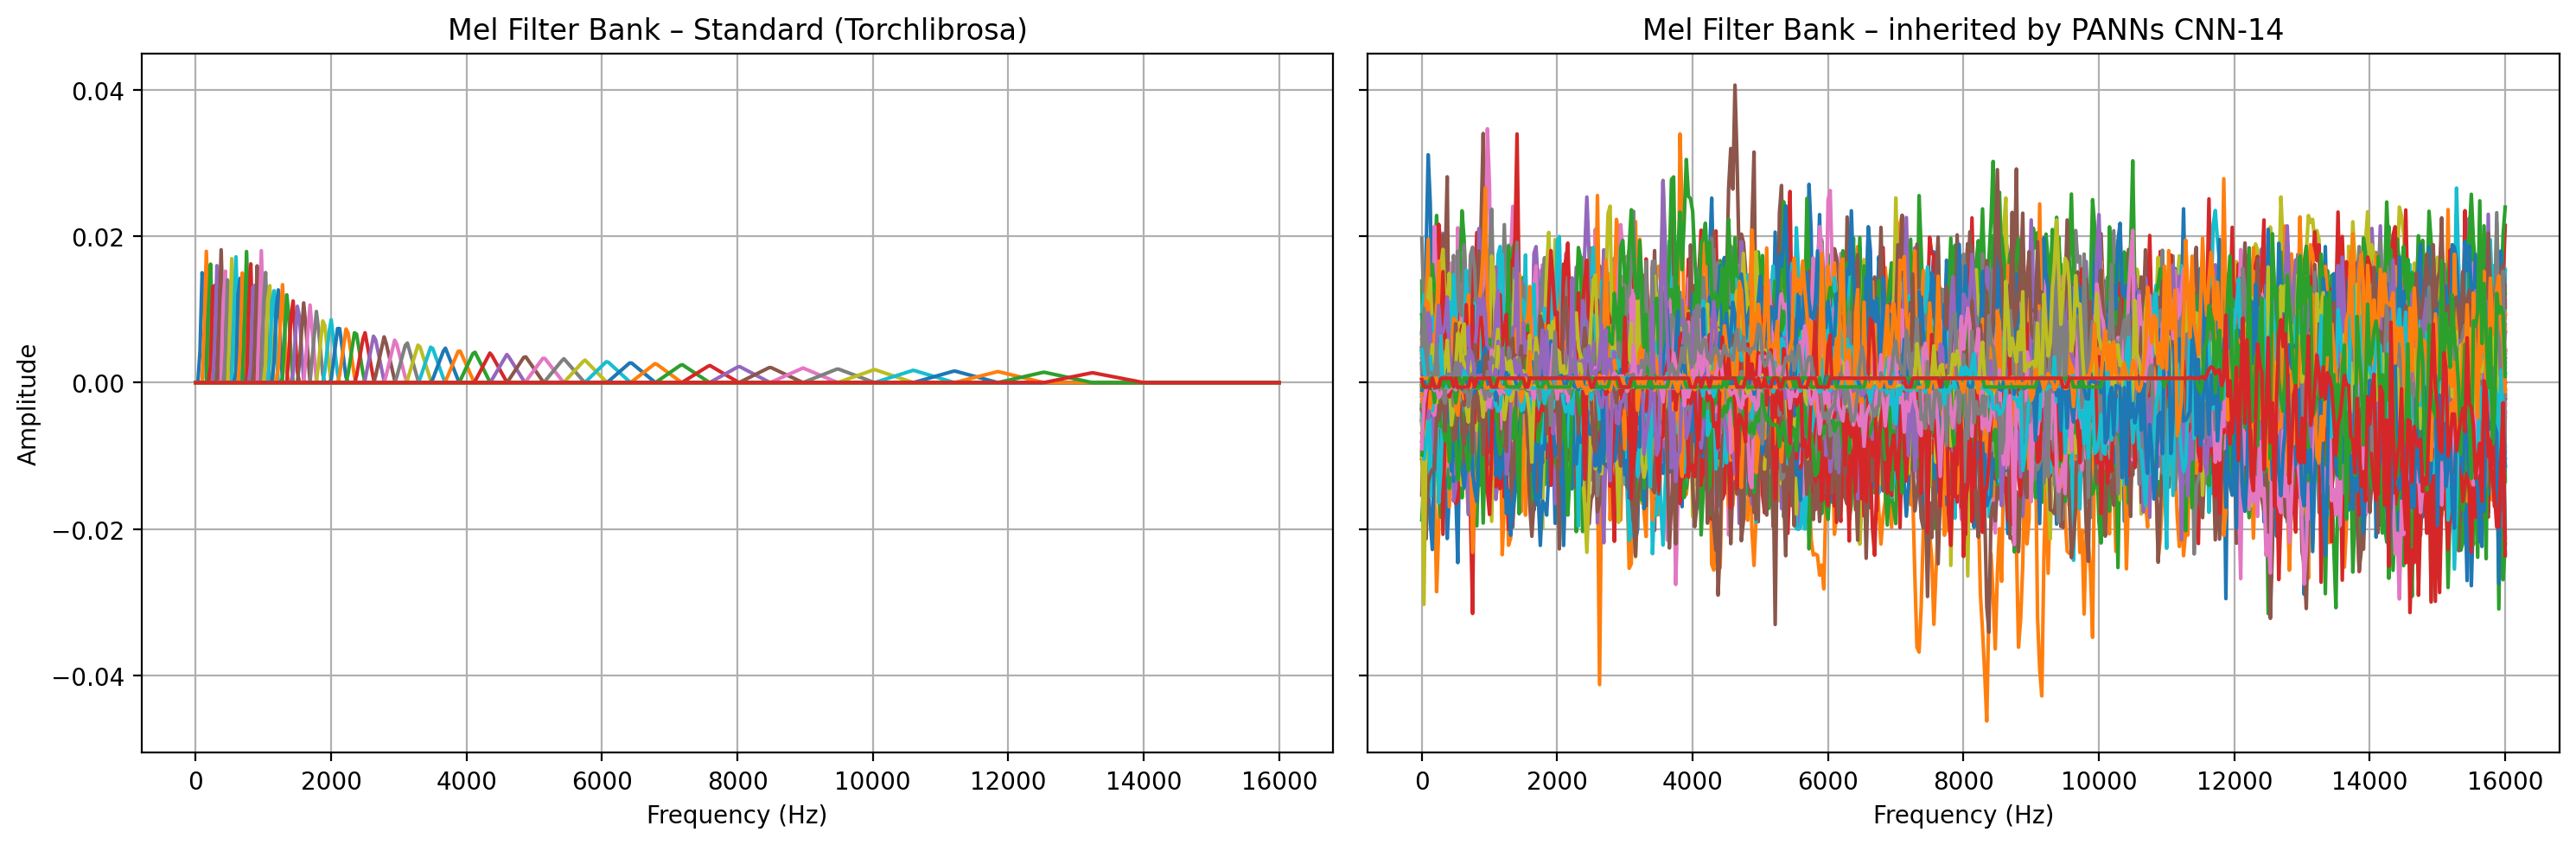

In [56]:
plot_filterbank_comparison(model, log_freq_axis=False)

In [53]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_learned_filterbank_subset(model, num_filters, sr=32000, n_fft=1024, log_freq_axis=False):
    """
    Displays one or more mel filters learned by the model in the frequency domain.

    Args:
        model: PyTorch model with a logmel_extractor containing a trainable 'melW' matrix.
        num_filters: int (single index) or list/tuple [start, end] for a filter range (inclusive).
        sr: Sample rate in Hz.
        n_fft: FFT size (used to define the frequency axis).
        log_freq_axis: If True, use logarithmic x-axis (frequency).
    """
    # Extract learned mel filter weights
    with torch.no_grad():
        for name, param in model.logmel_extractor.named_parameters():
            if 'melW' in name:
                learned_fb = param.cpu().numpy().T  # shape: (n_mels, n_freqs)
                break
        else:
            raise ValueError("No 'melW' found in model.logmel_extractor")

    # Create linear frequency axis
    freqs = np.linspace(0, sr // 2, learned_fb.shape[1])

    # Determine which filters to plot
    if isinstance(num_filters, int):
        indices = [num_filters]
        title = f"Learned Mel Filter: Index-{num_filters}"
    elif isinstance(num_filters, (list, tuple)) and len(num_filters) == 2:
        start, end = num_filters
        indices = list(range(start, end + 1))
        title = f"Learned Mel Filters [{start} to {end}]"
    else:
        raise ValueError("num_filters must be an integer or a list/tuple [start, end]")

    # Plot selected filters
    plt.figure(figsize=(15, 5))
    for i in indices:
        if i >= learned_fb.shape[0]:
            continue  # Avoid out-of-bounds filters
        plt.plot(freqs, learned_fb[i], alpha=0.8, label=f'Filter {i}')
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    if log_freq_axis:
        plt.xscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

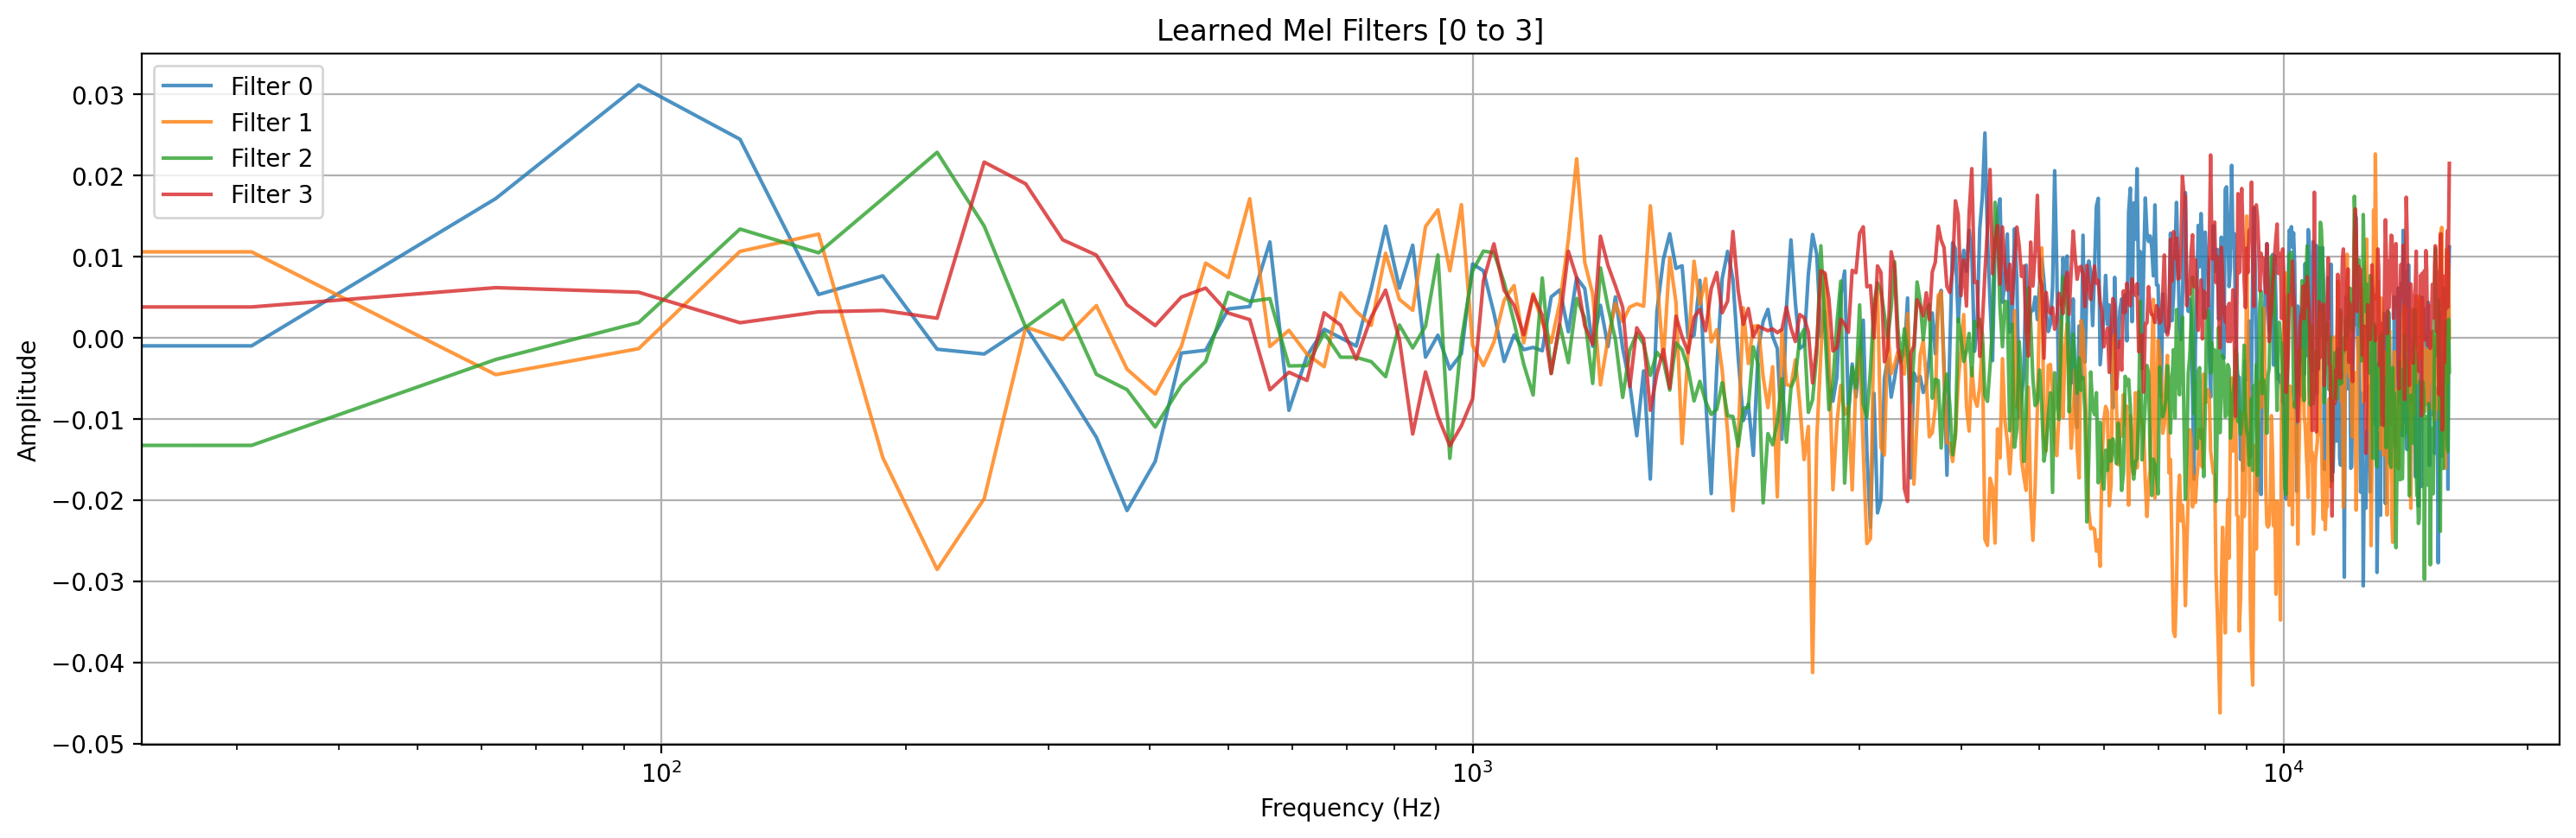

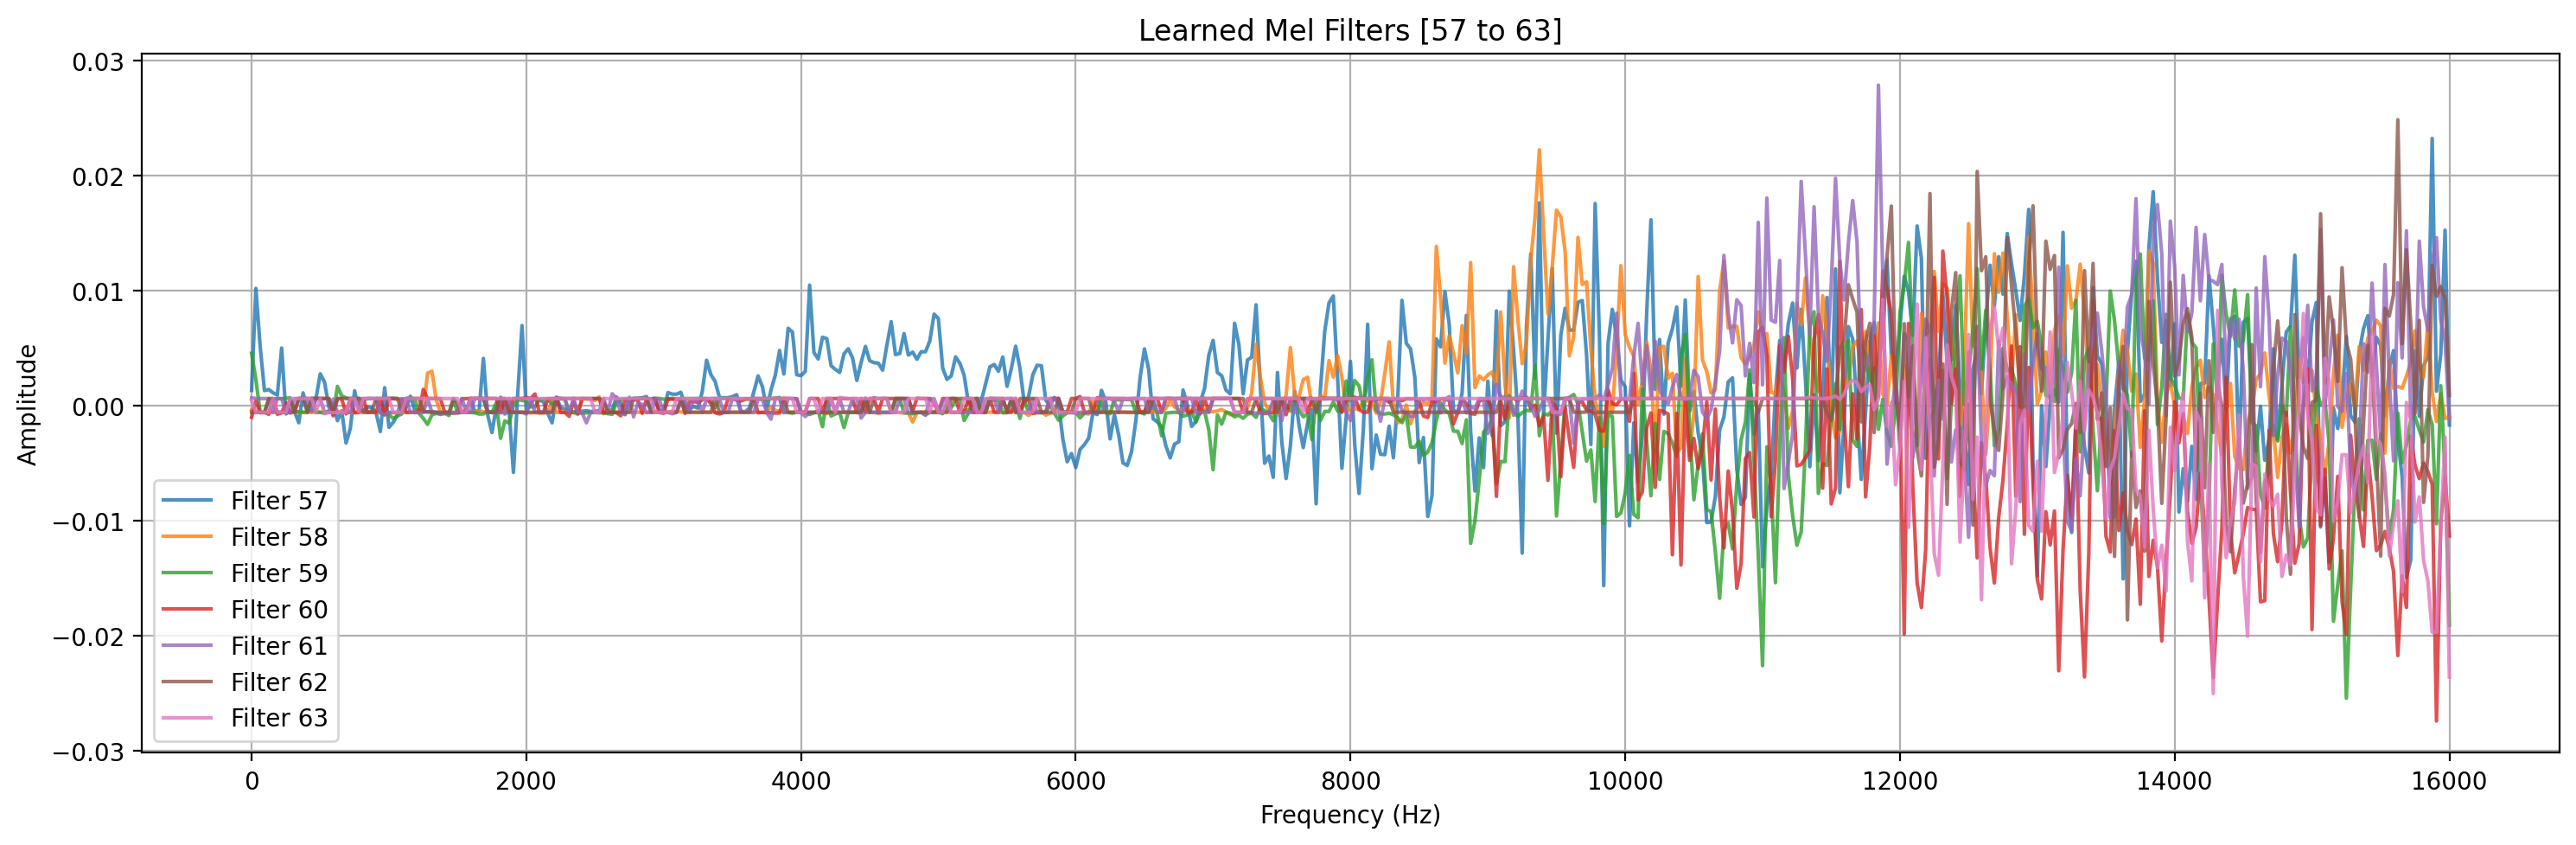

In [54]:
plot_learned_filterbank_subset(model, [0, 3], log_freq_axis=True)
plot_learned_filterbank_subset(model, [57, 63], log_freq_axis=False)

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchlibrosa as tl

def compute_centroids_and_peaks(filterbank, sr=32000):
    """
    Compute centroid and peak frequency for each filter in a mel filter bank.
    """
    n_mels, n_freqs = filterbank.shape
    freqs = np.linspace(0, sr / 2, n_freqs)
    centroids = np.zeros(n_mels)
    peaks = np.zeros(n_mels)

    for i, w in enumerate(filterbank):
        w_pos = np.clip(w, a_min=0, a_max=None)
        total = w_pos.sum()
        centroids[i] = (w_pos * freqs).sum() / total if total > 0 else 0.0
        peaks[i] = freqs[np.argmax(w_pos)]

    return centroids, peaks

def compare_filterbank_centroids(model, sr=32000, n_fft=1024, n_mels=64, fmin=50, fmax=14000):
    """
    Compare centroid and peak frequencies of mel filters between standard and learned versions.
    Creates two side-by-side subplots.
    """
    # 1. Learned filters from the model
    with torch.no_grad():
        for name, param in model.logmel_extractor.named_parameters():
            if 'melW' in name:
                learned_fb = param.cpu().numpy().T
                break
        else:
            raise ValueError("No 'melW' found in model.logmel_extractor")

    # 2. Standard filters from torchlibrosa
    with torch.no_grad():
        standard_logmel = tl.LogmelFilterBank(
            sr=sr,
            n_fft=n_fft,
            n_mels=n_mels,
            fmin=fmin,
            fmax=fmax,
            ref=1.0,
            amin=1e-10,
            top_db=None,
            is_log=True
        )
        for name, param in standard_logmel.named_parameters():
            if 'melW' in name:
                standard_fb = param.cpu().numpy().T
                break
        else:
            raise ValueError("No 'melW' found in standard_logmel")

    # 3. Compute values
    idx = np.arange(n_mels)
    centroids_std, peaks_std = compute_centroids_and_peaks(standard_fb, sr)
    centroids_learned, peaks_learned = compute_centroids_and_peaks(learned_fb, sr)

    # 4. Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Left: standard
    axs[0].plot(idx, centroids_std, label='Centroid', linestyle='--', color='gray')
    axs[0].scatter(idx, peaks_std, label='Peak', color='black', marker='o')
    axs[0].set_title("Standard Mel Filter Bank (Torchlibrosa)")
    axs[0].set_xlabel("Filter Index")
    axs[0].set_ylabel("Frequency (Hz)")
    axs[0].grid(True)
    axs[0].legend()

    # Right: learned
    axs[1].plot(idx, centroids_learned, label='Centroid', linestyle='--', color='gray')
    axs[1].scatter(idx, peaks_learned, label='Peak', color='black', marker='o')
    axs[1].set_title("Learned Mel Filter Bank (CNN-14 pre-training)")
    axs[1].set_xlabel("Filter Index")
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

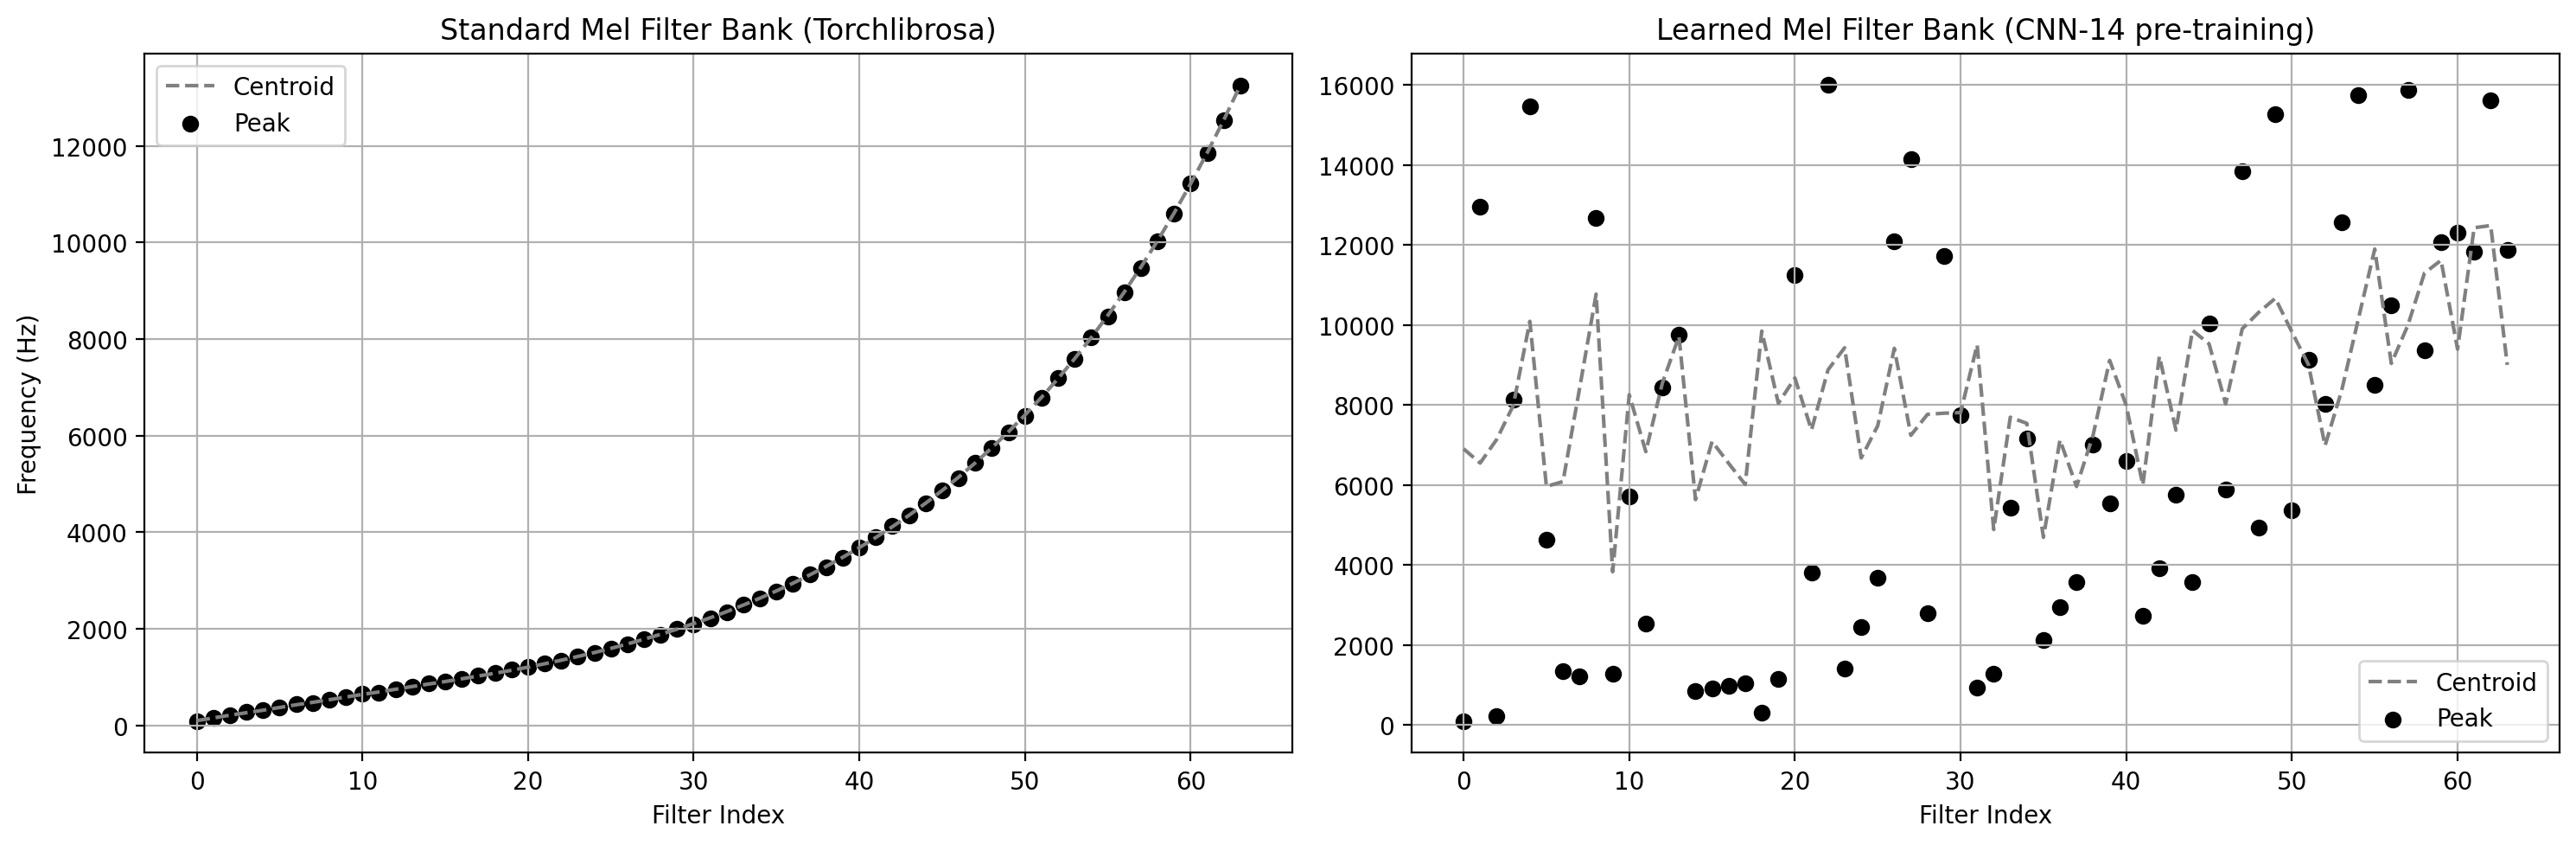

In [19]:
compare_filterbank_centroids(model)

# VanillaBackprop

In [ ]:
class VanillaBackprop():
    """
    Vanilla Backpropagation focused on the Emergency Vehicle (class 322) detection
    """
    def __init__(self, model, target_layer='conv_block1', class_index=322):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.target_layer = target_layer
        self.class_index = class_index
        self._register_hook()

    def _register_hook(self):
        def hook_fn(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        target_module = getattr(self.model, self.target_layer)
        target_module.register_full_backward_hook(hook_fn)

    def generate_gradients(self, input_waveform):
        """
        Args:
            input_waveform: (1, samples) waveform tensor
        Returns:
            raw_grads: gradients w.r.t. logmel features [T, F]
            norm_grads: normalized gradients [T, F] for visualization
        """

        # Forward
        logits = self.model(input_waveform.float())['clipwise_output']
        emergency_prob = logits[:, self.class_index]

        # Backward
        self.model.zero_grad()
        emergency_prob.sum().backward()

        # Extract gradient w.r.t. logmel features
        raw_grads = self.gradients.detach().clone()[0, 0]  # (1, 1, T, F) → (T, F)

        # Normalize
        norm_grads = raw_grads - raw_grads.min()
        norm_grads /= (norm_grads.max() + 1e-6)

        return raw_grads, norm_grads.cpu().numpy()

## ConvBlock 1

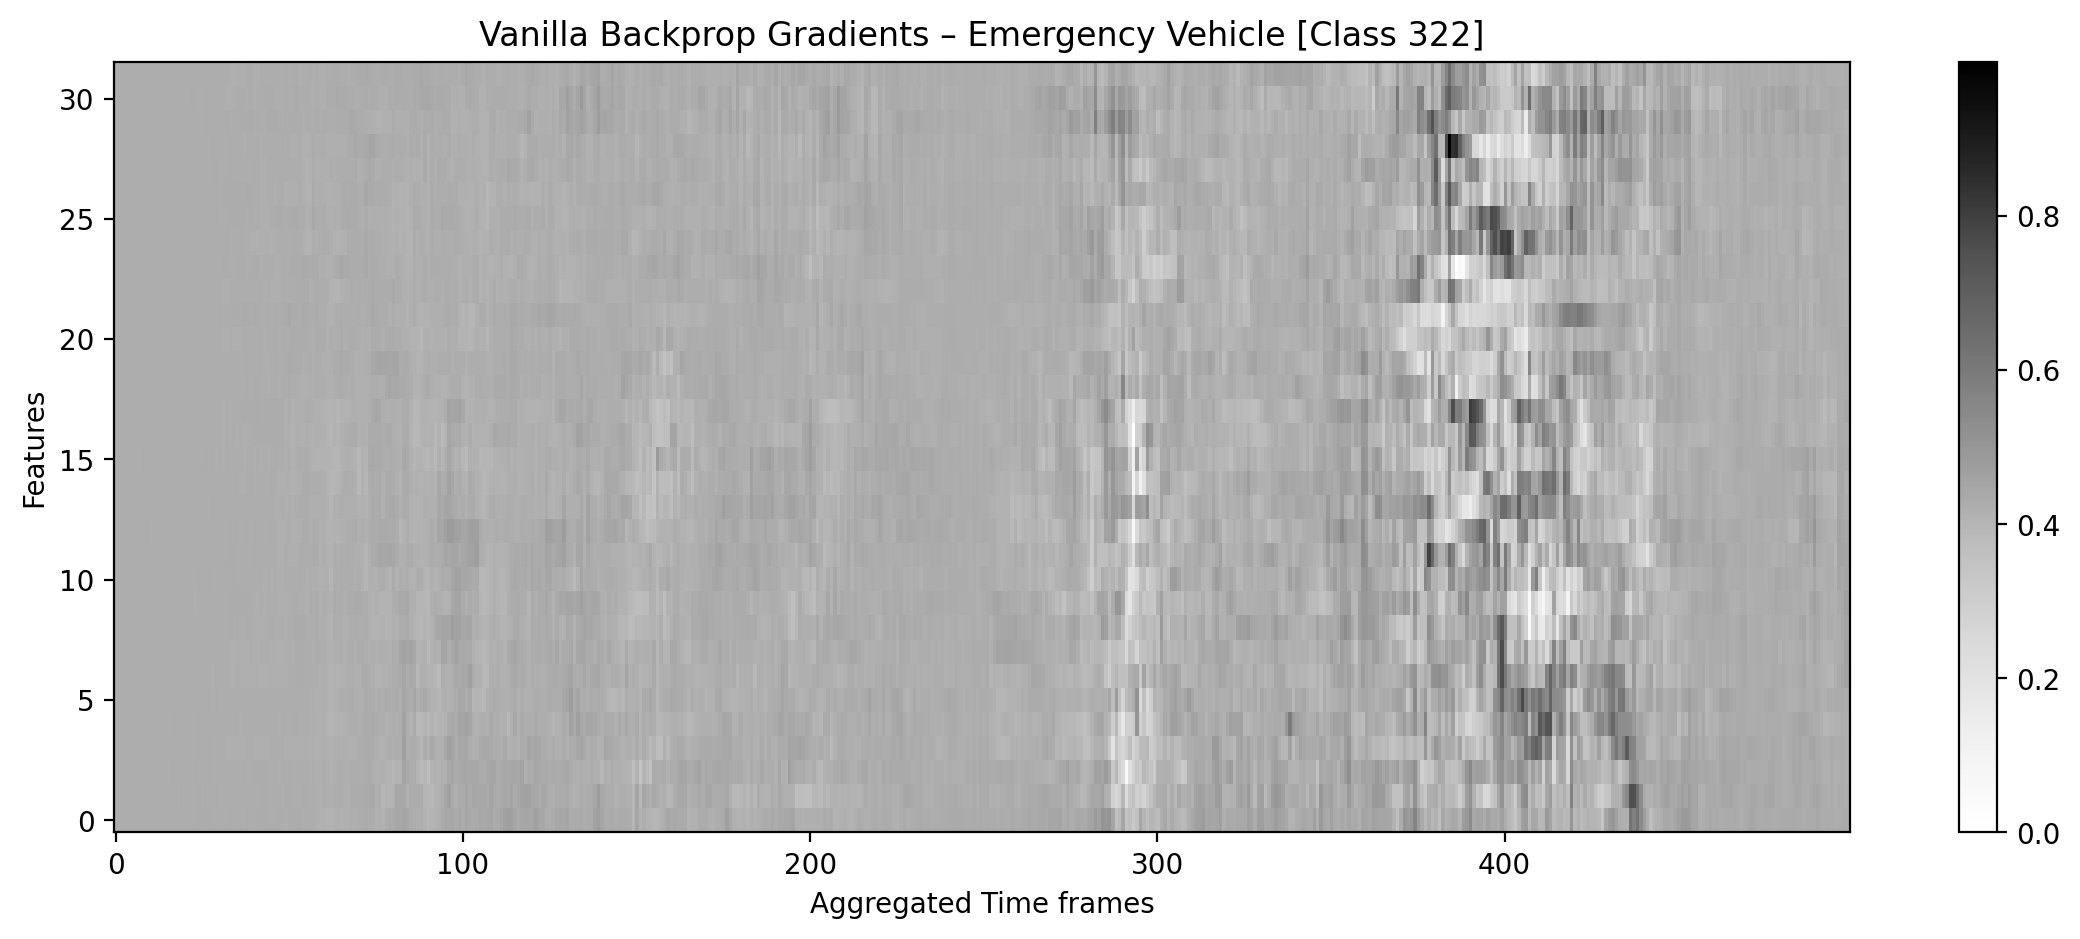

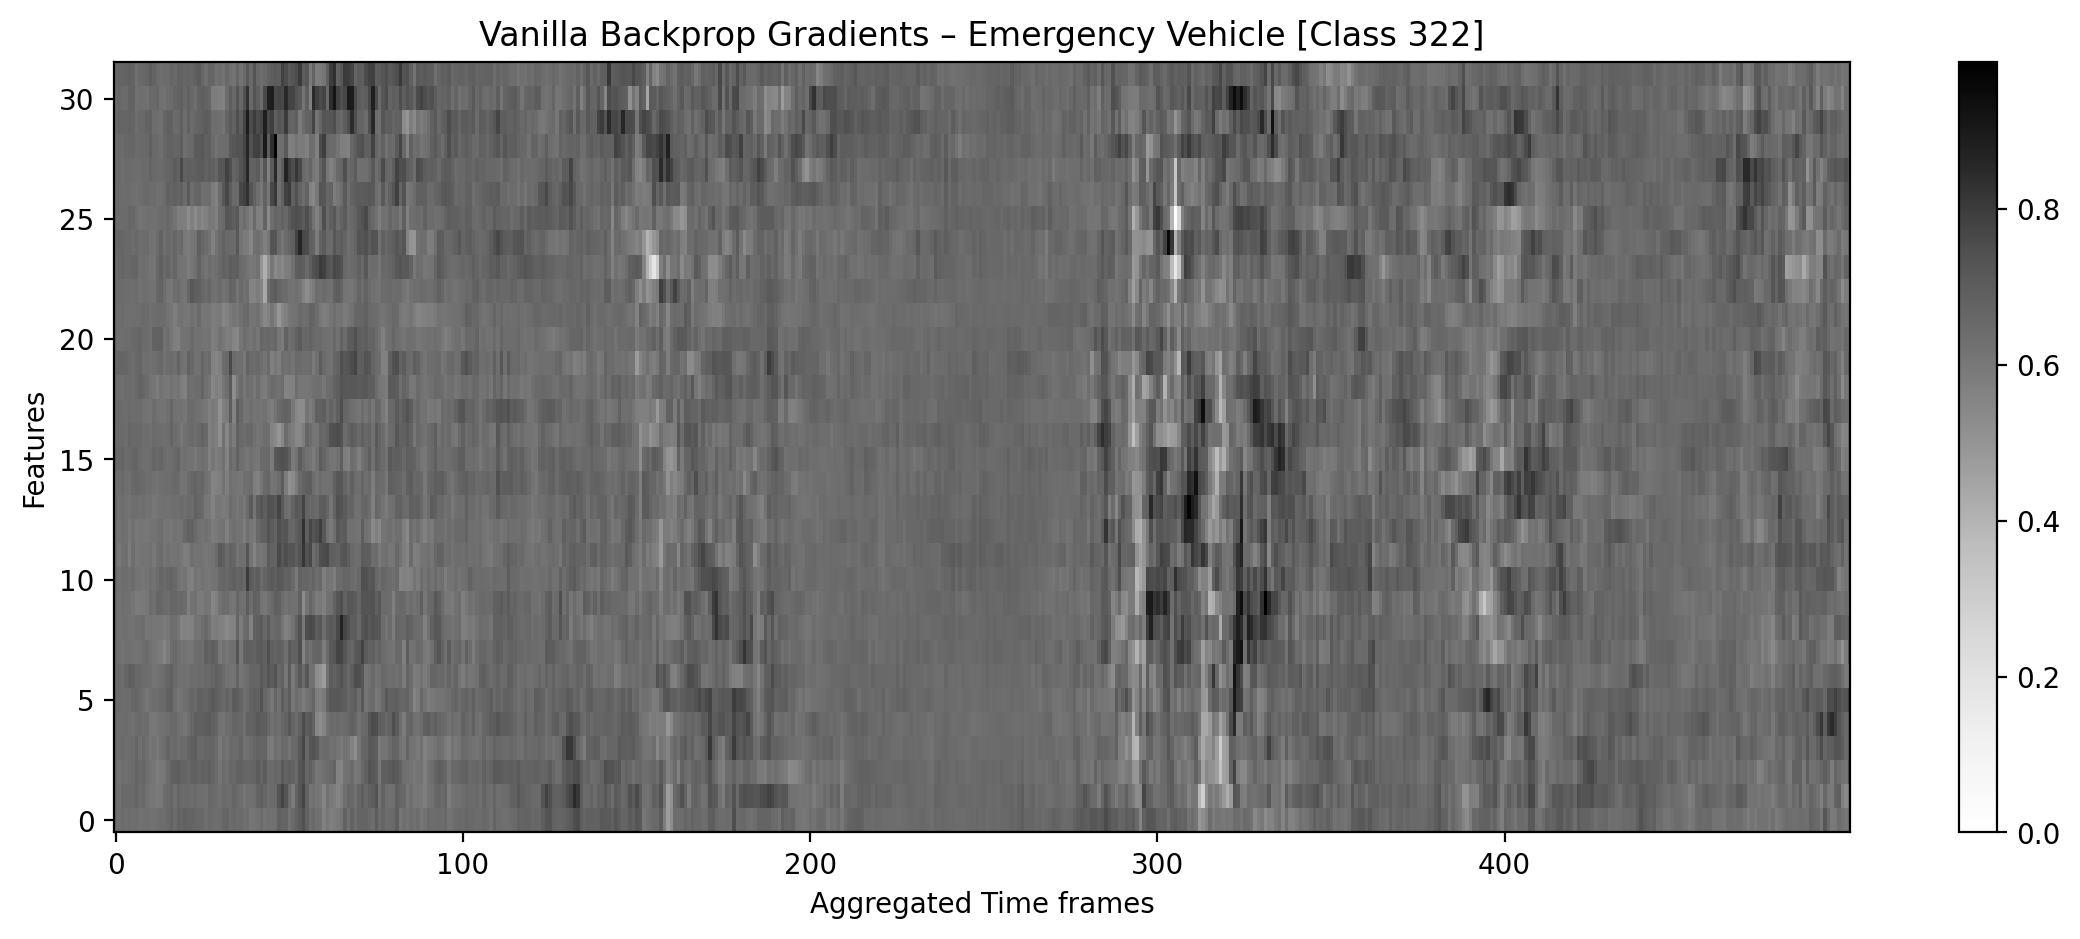

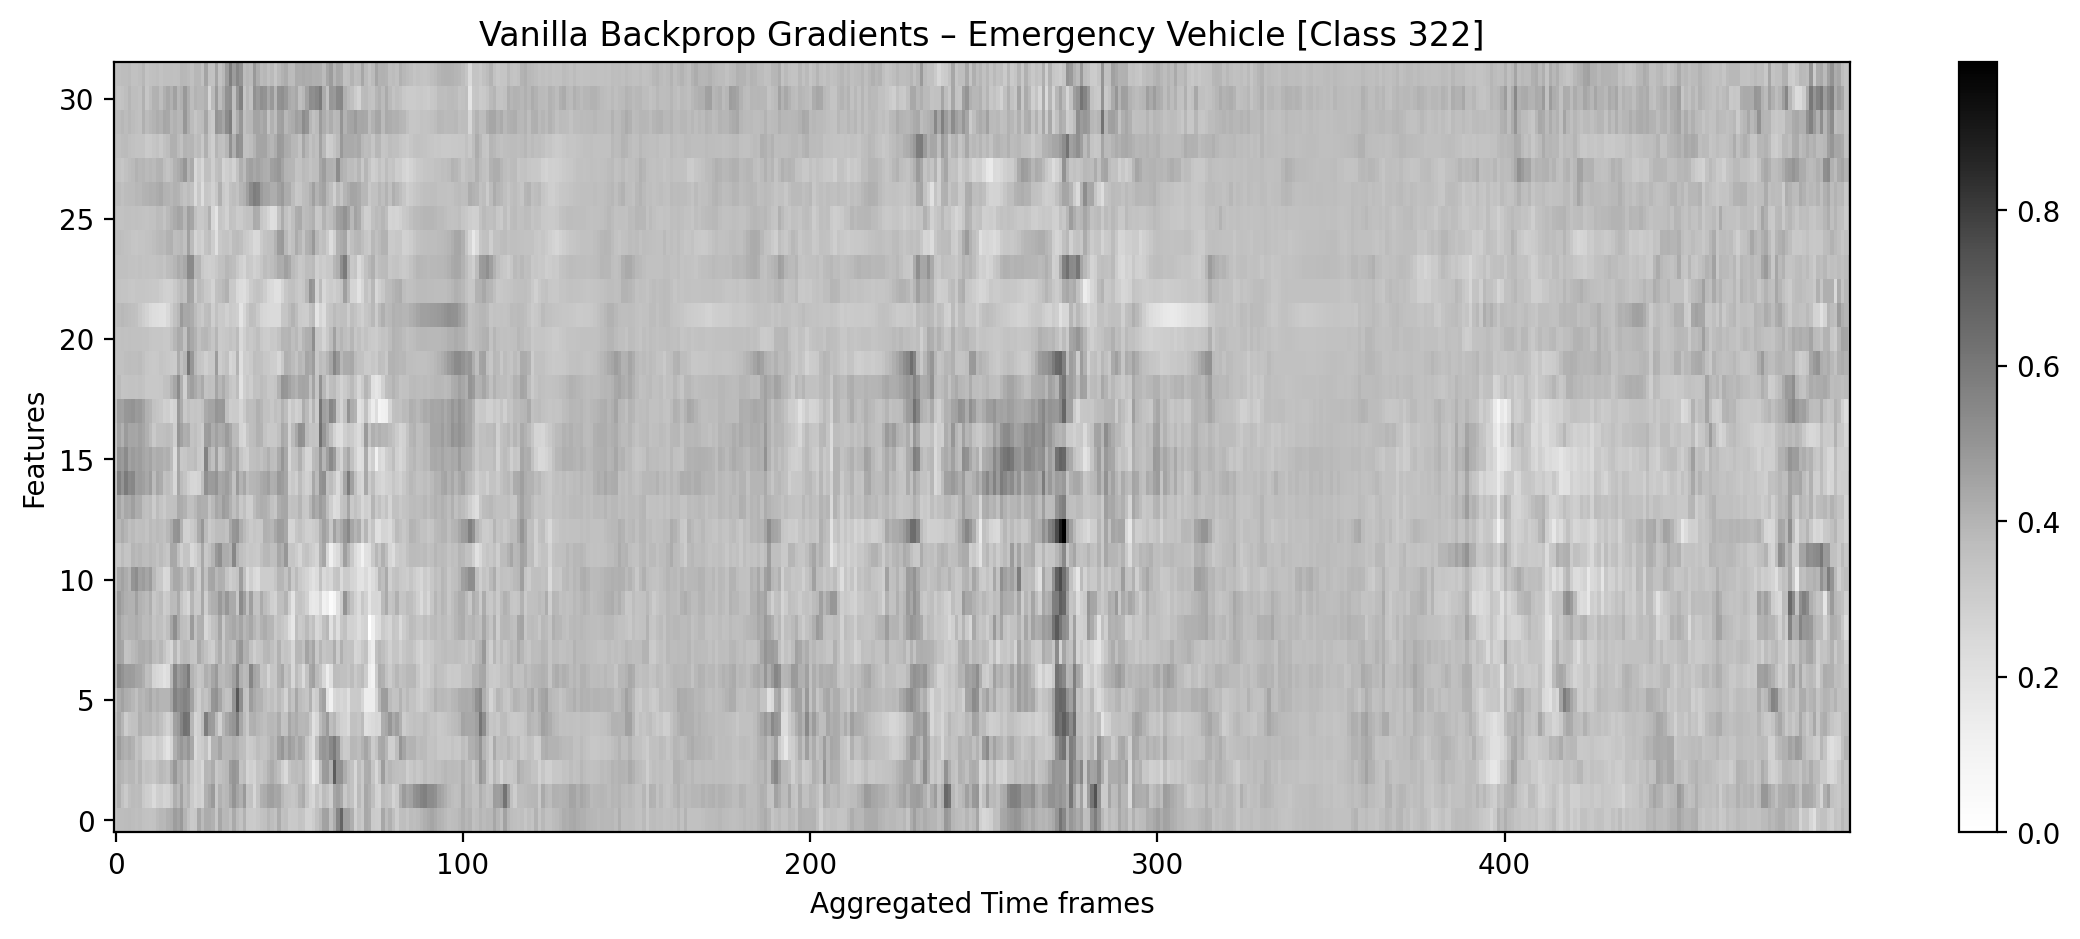

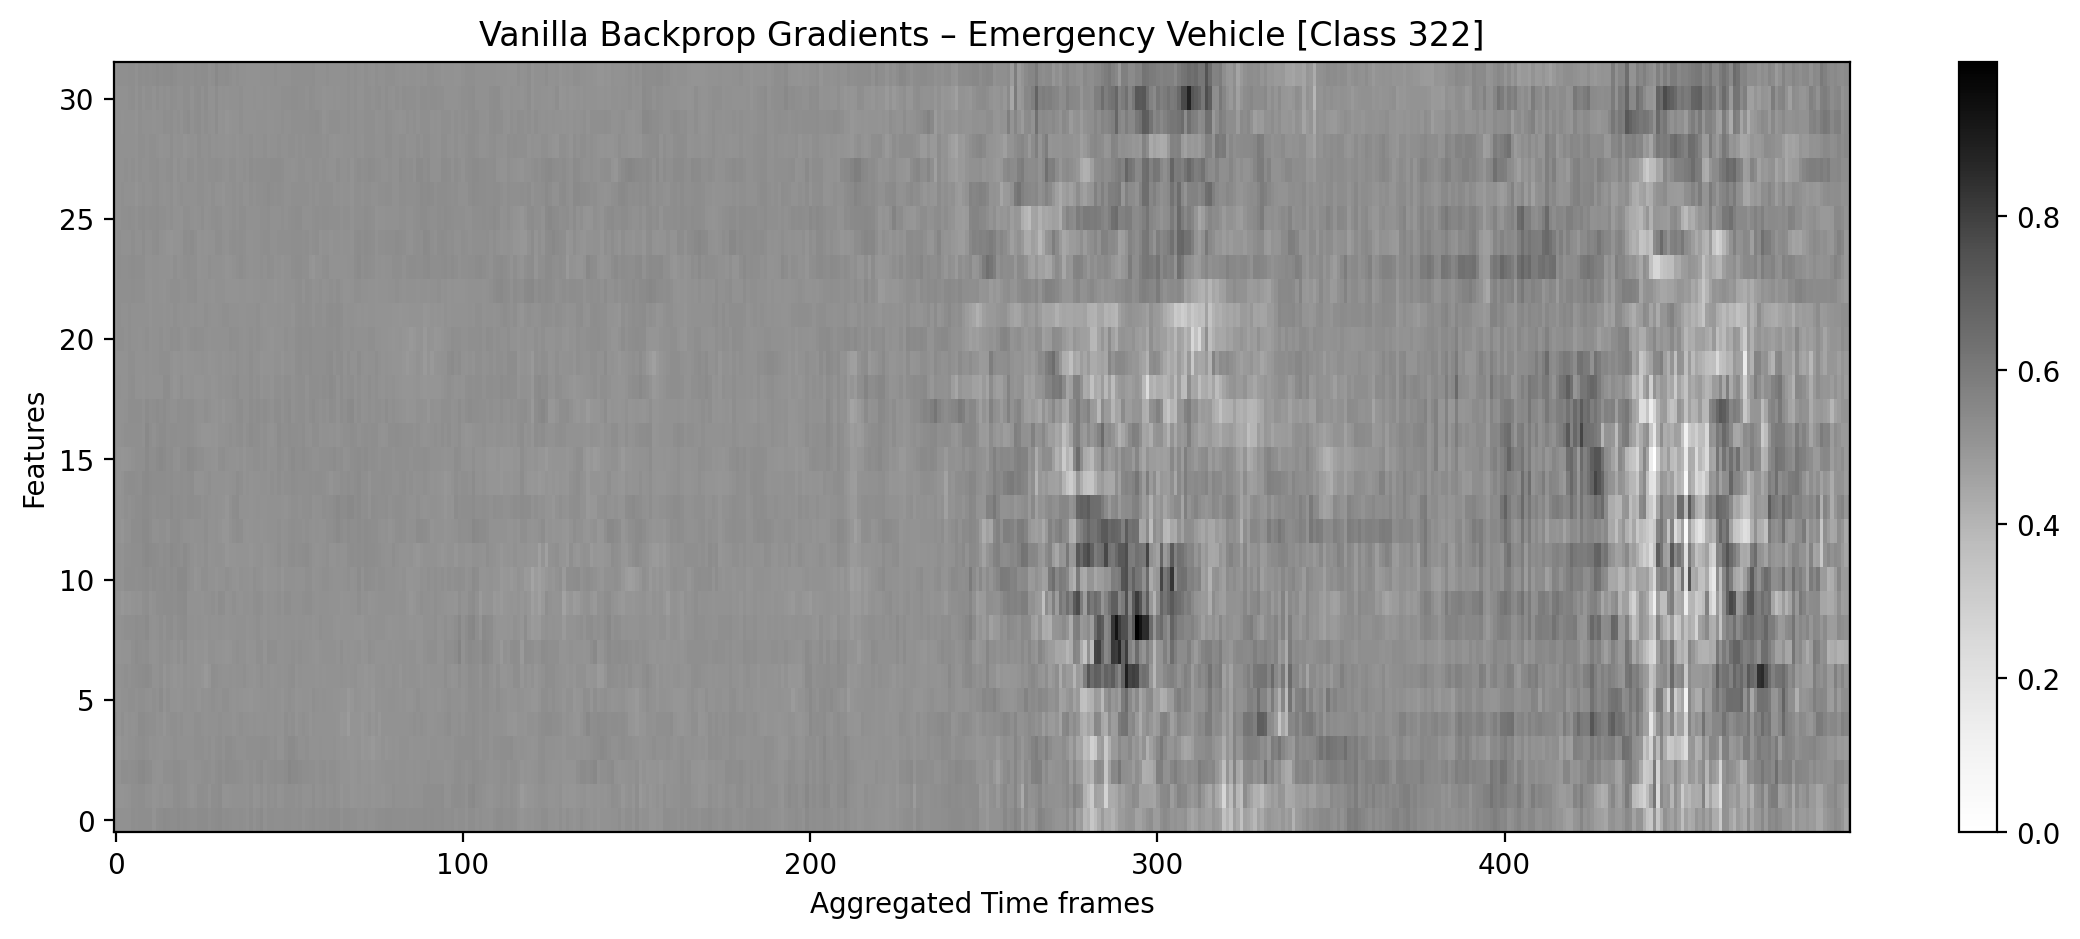

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block1')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

## ConvBlock 2

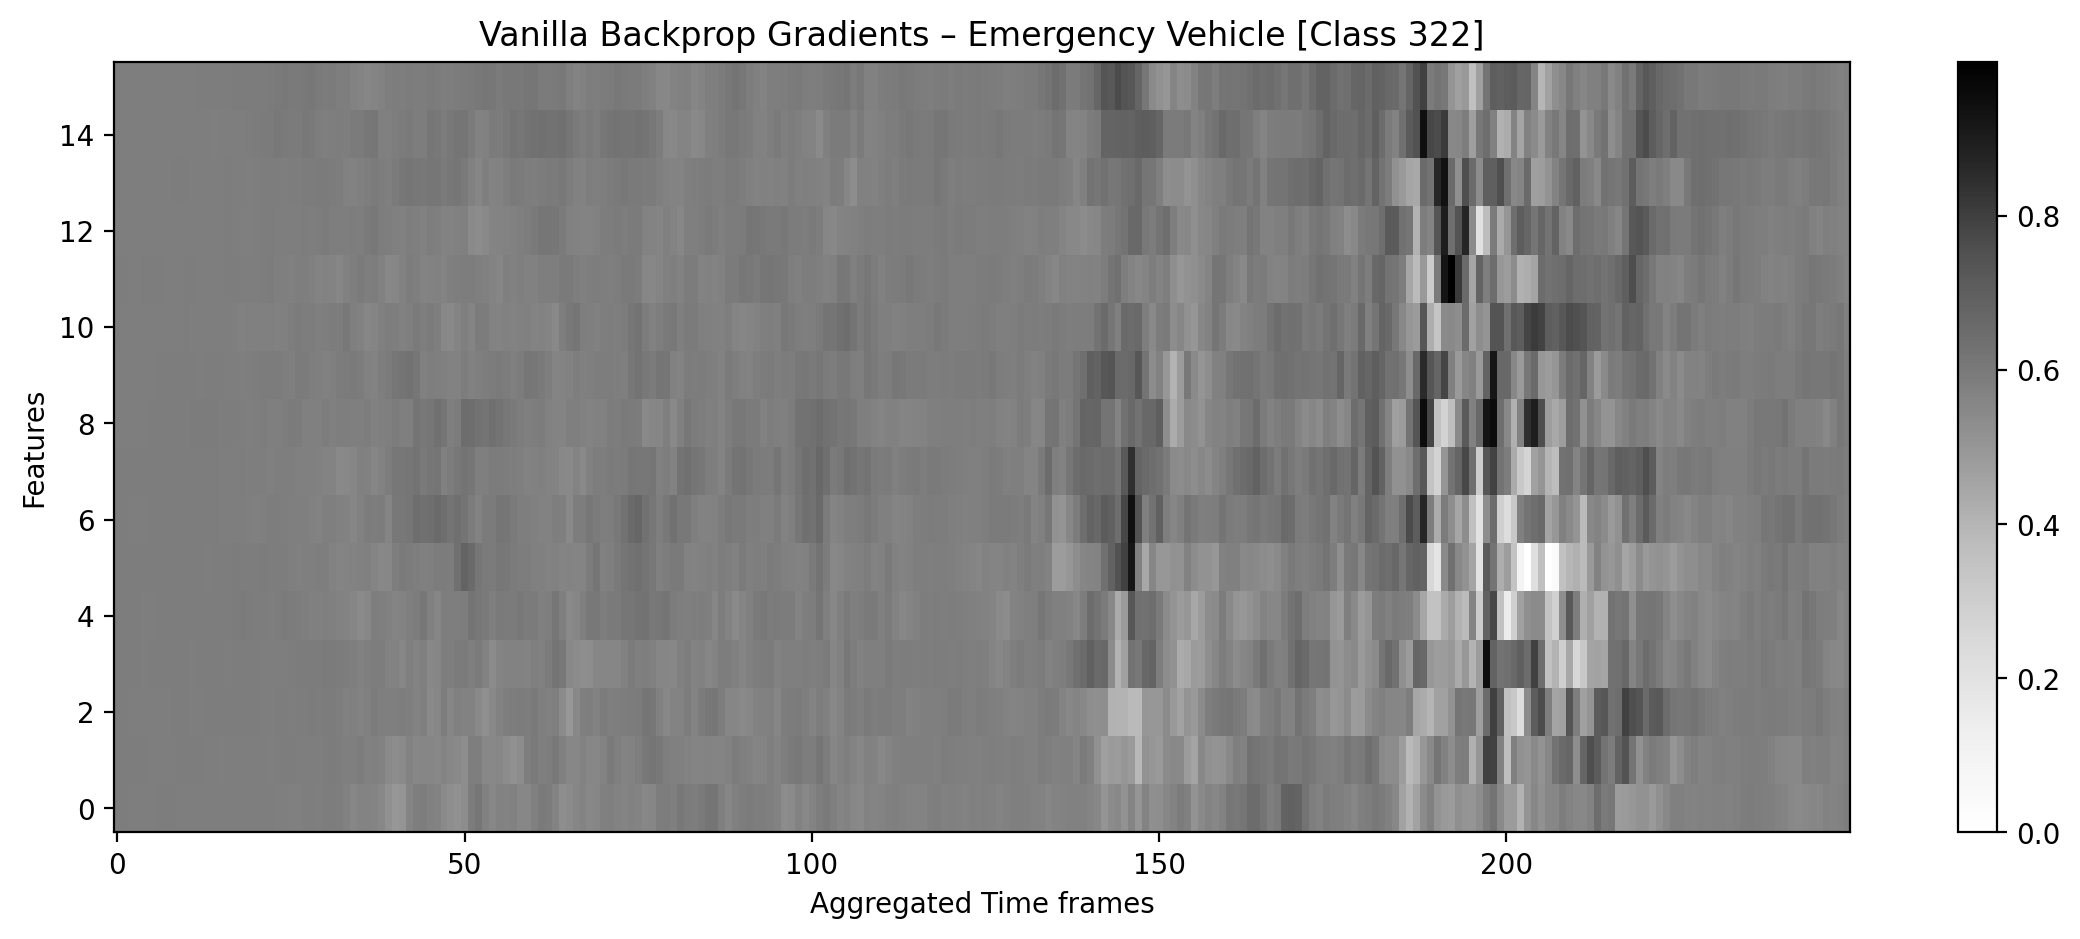

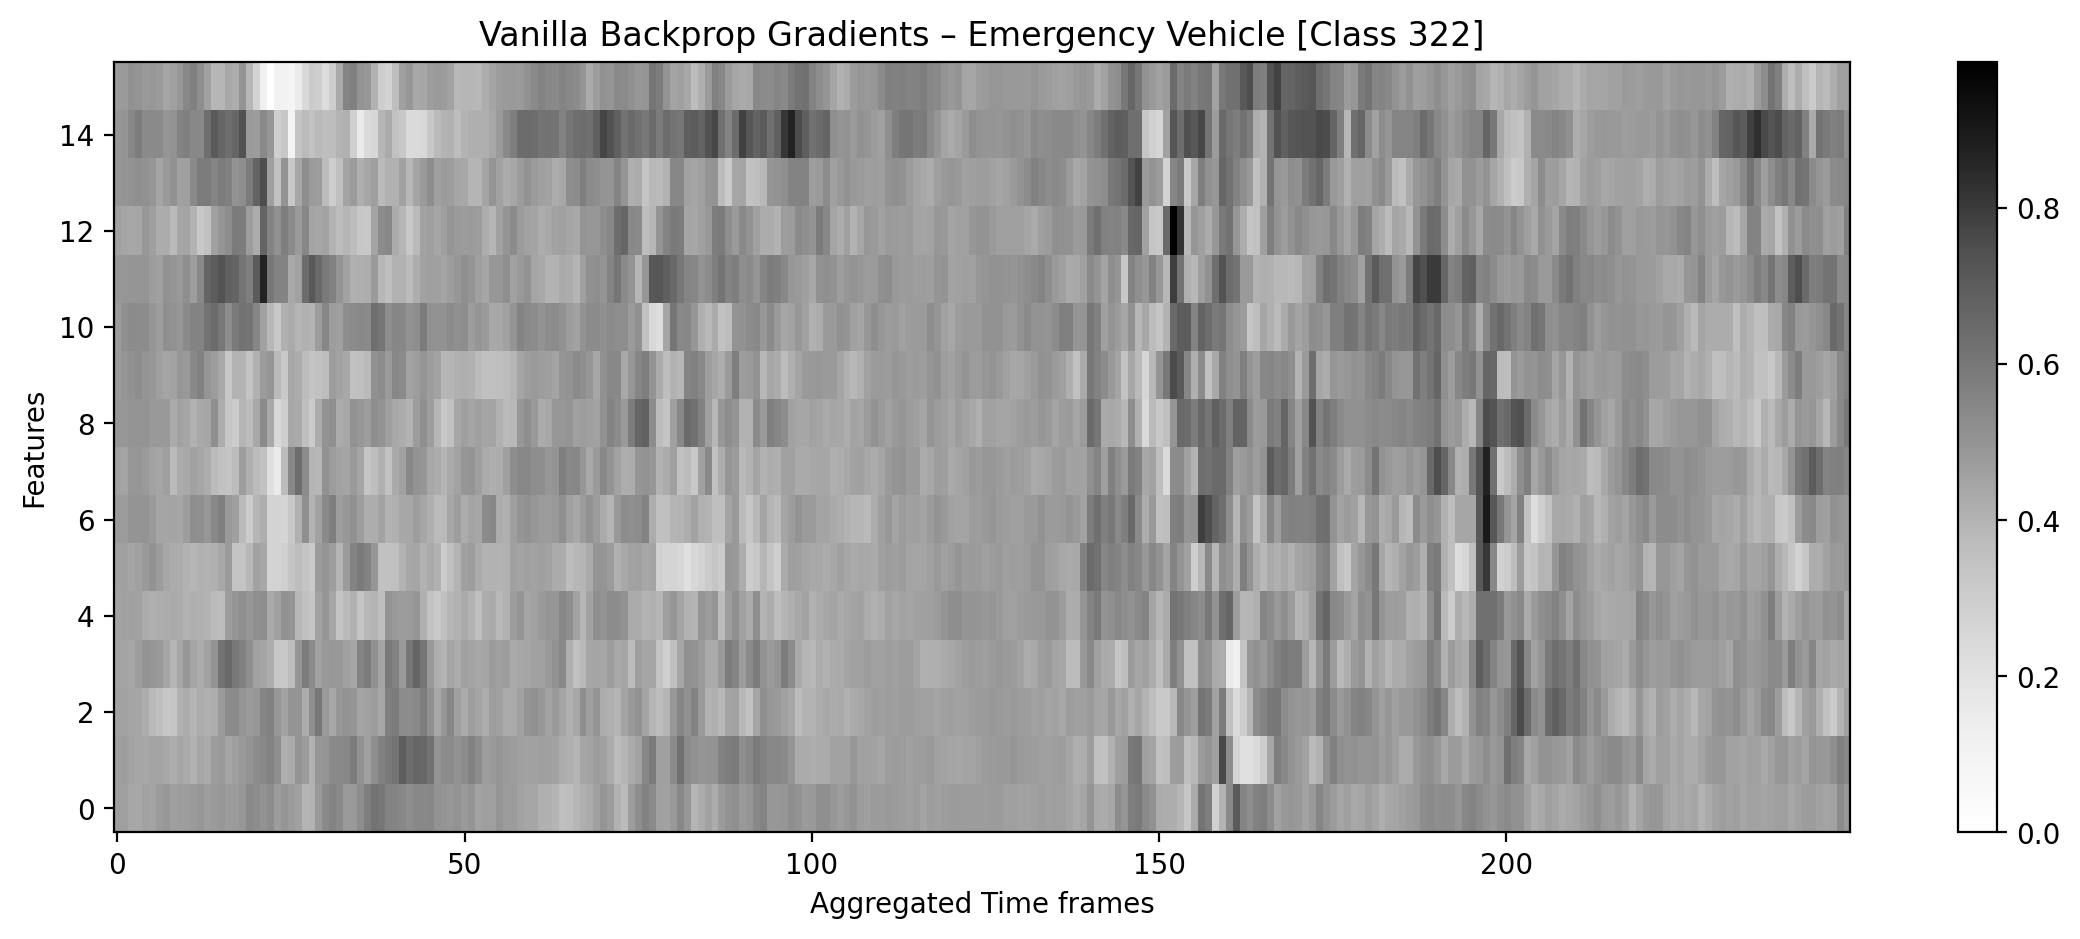

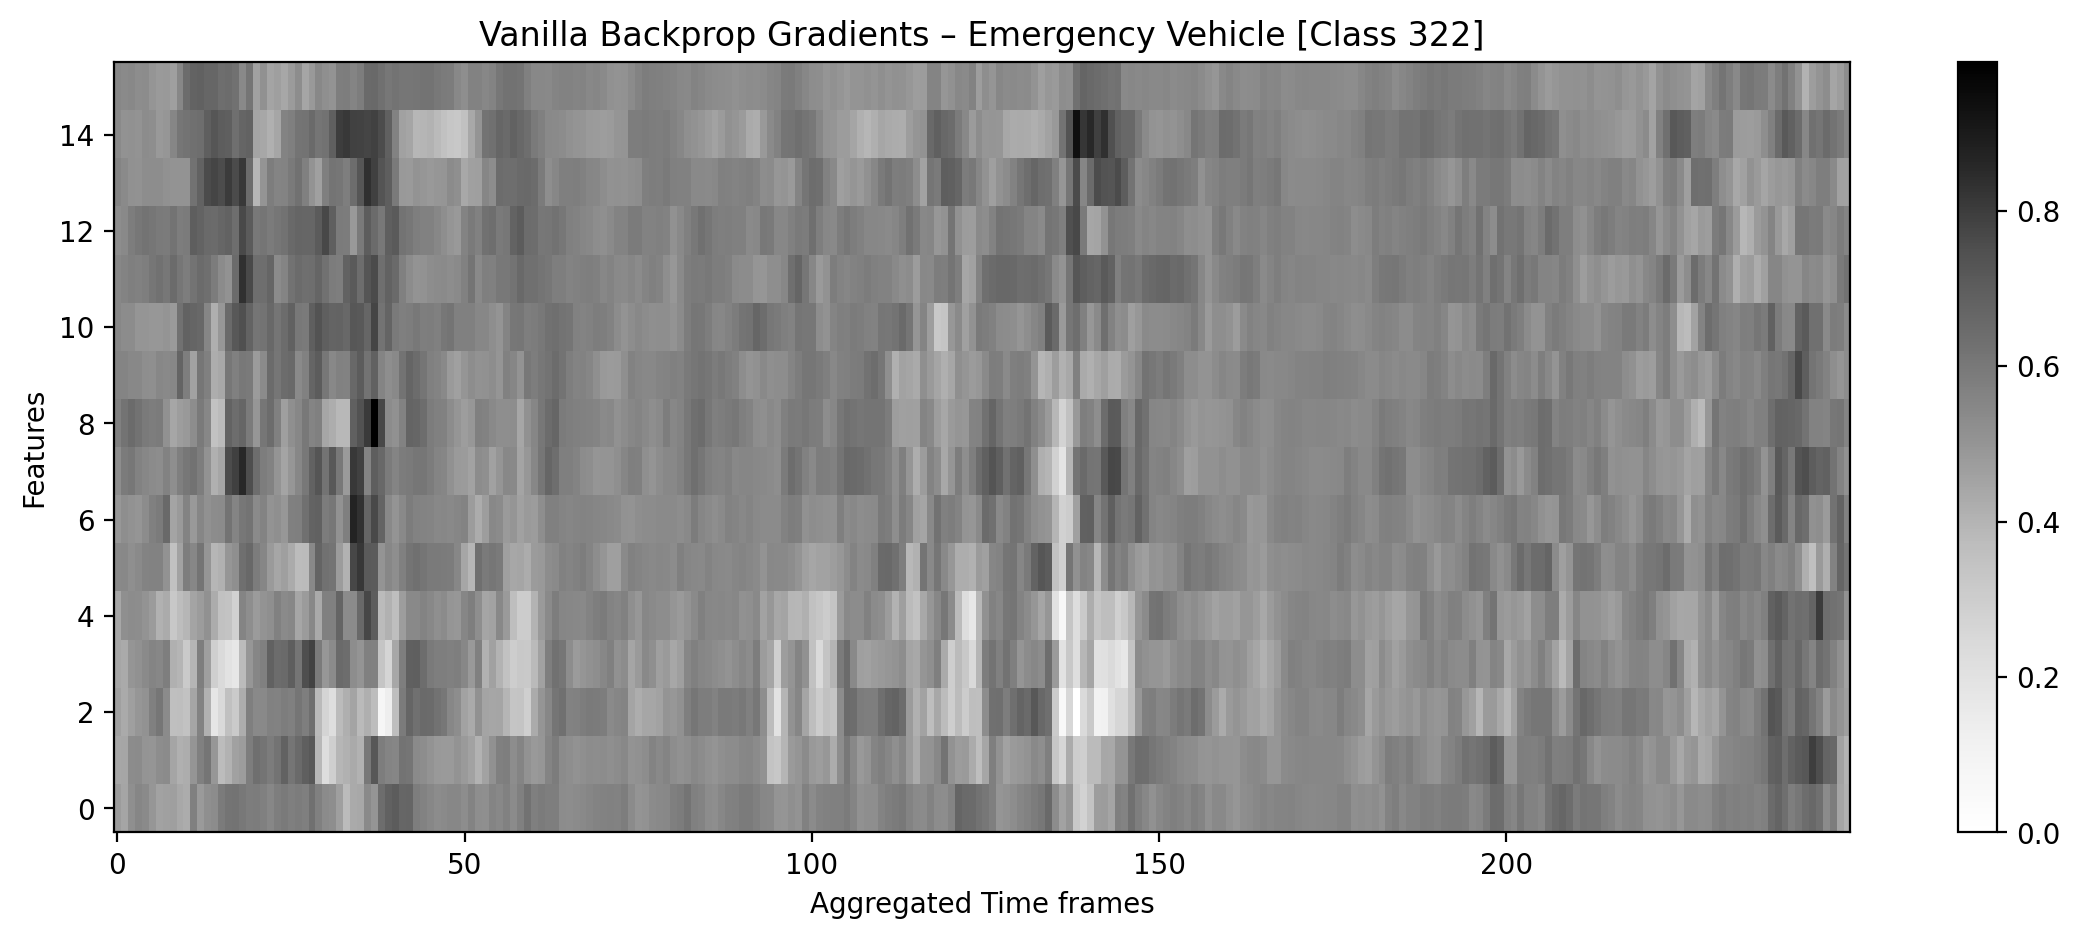

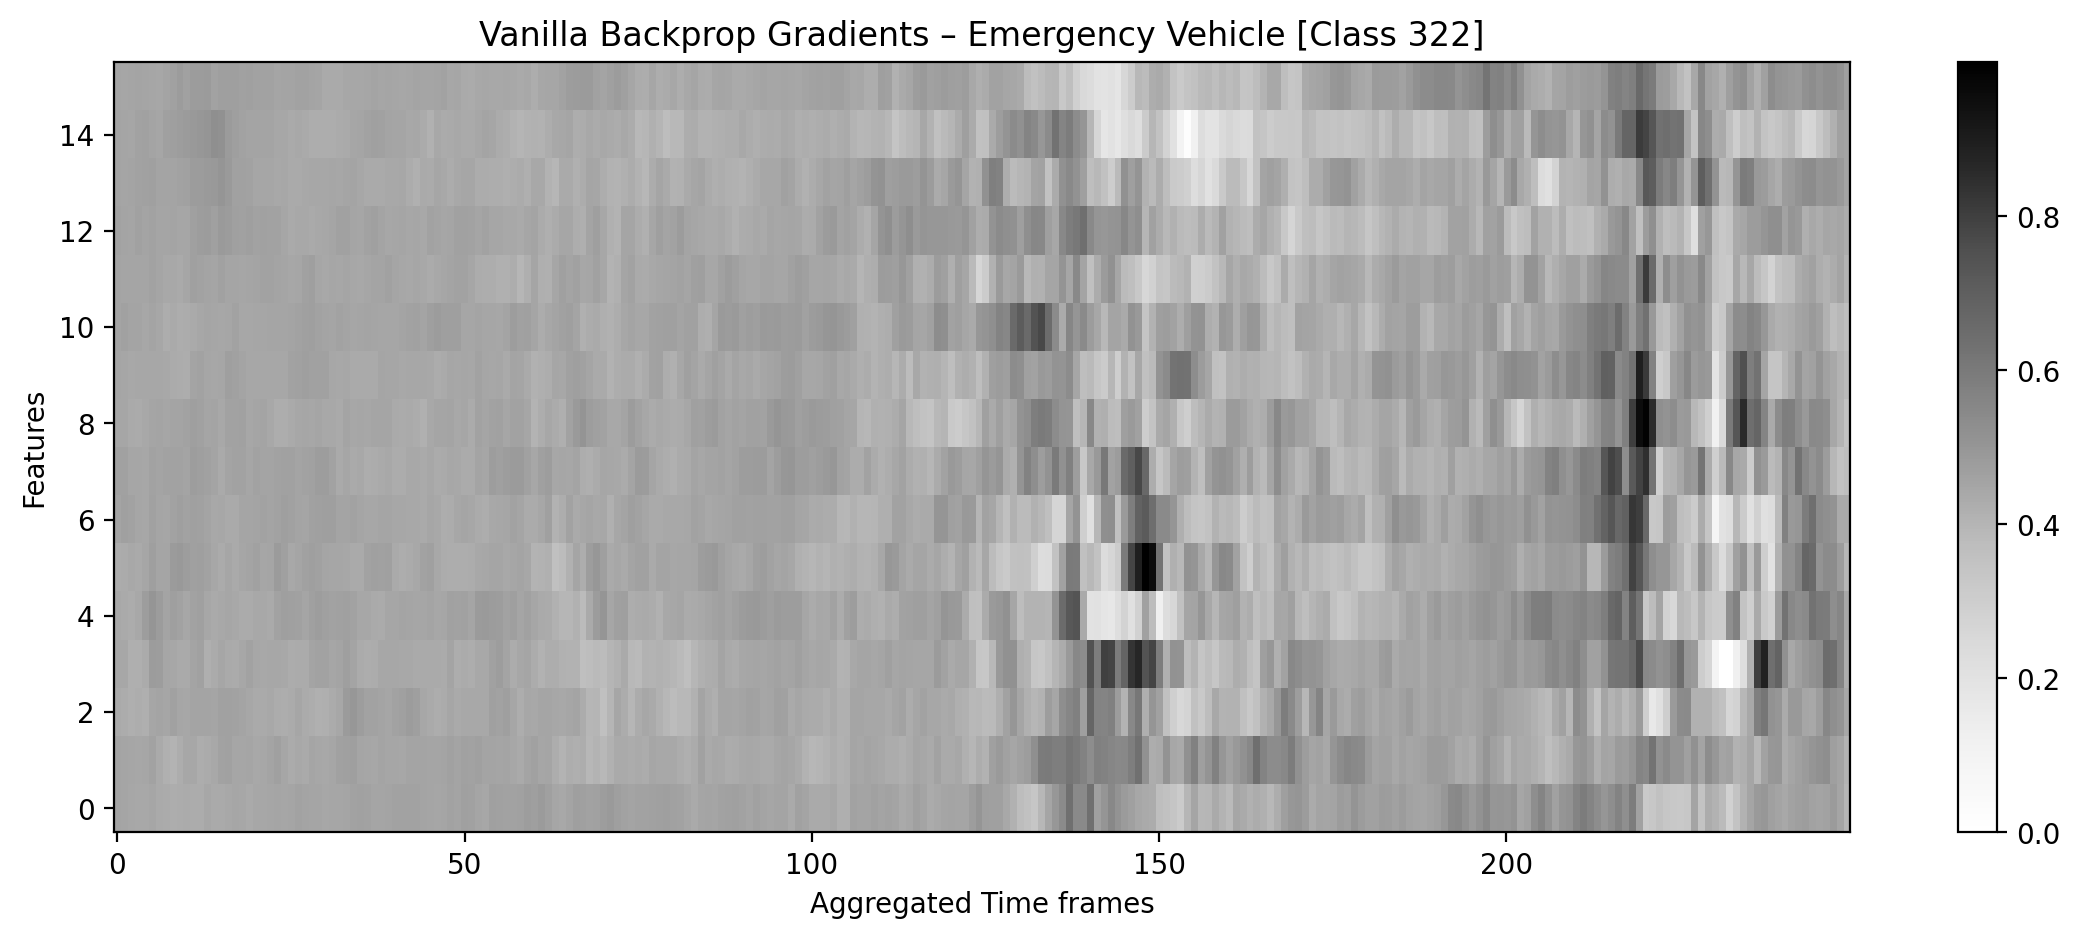

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block2')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

## ConvBlock 3

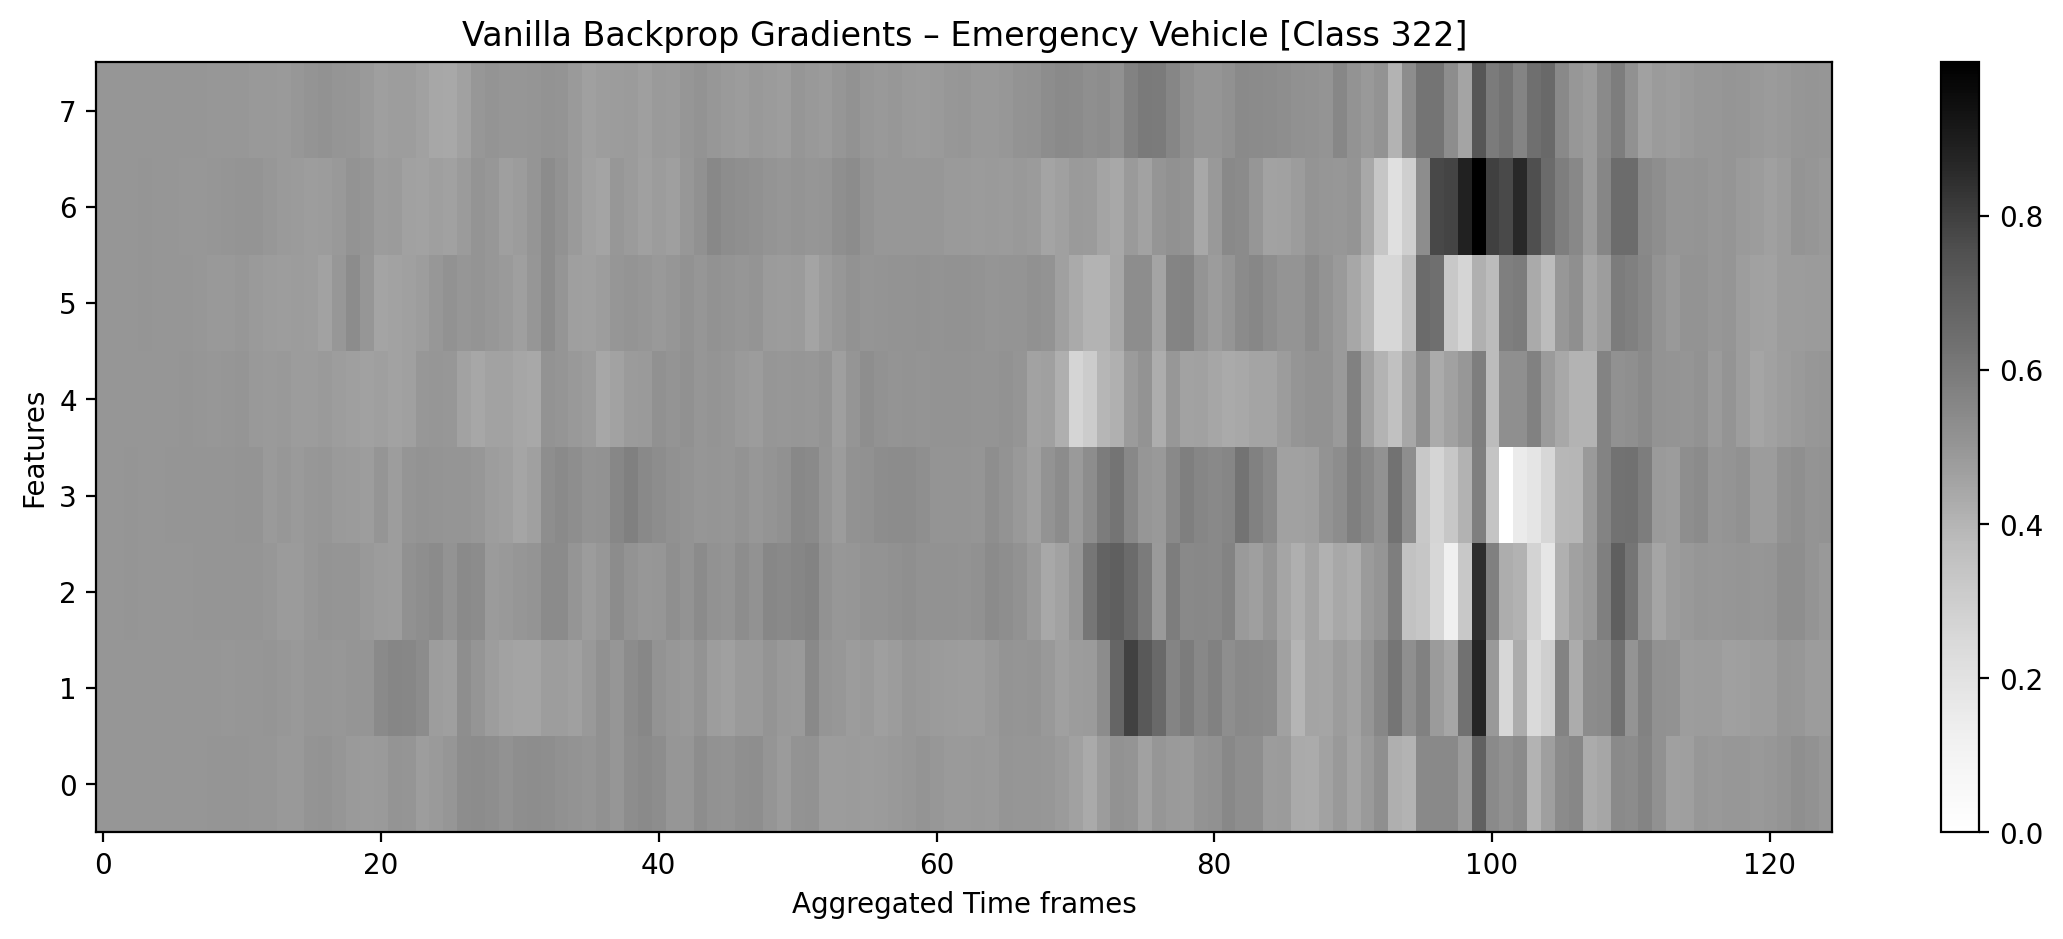

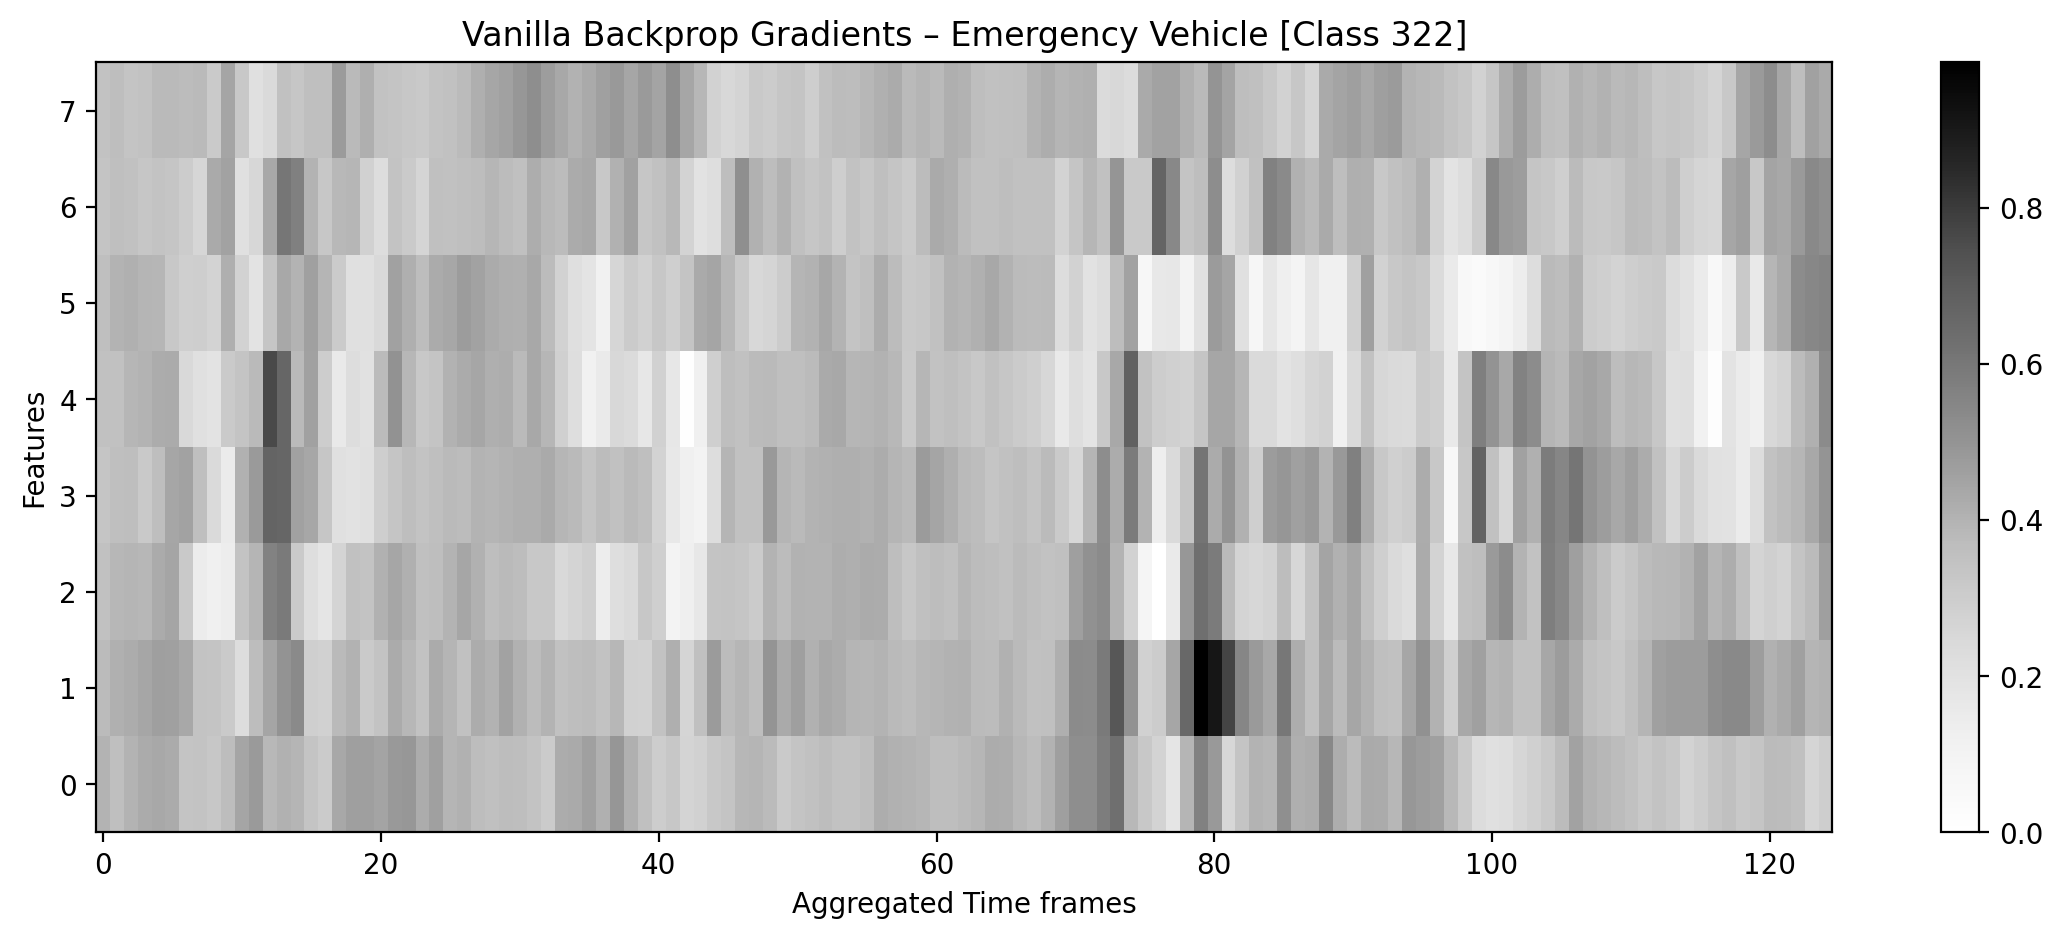

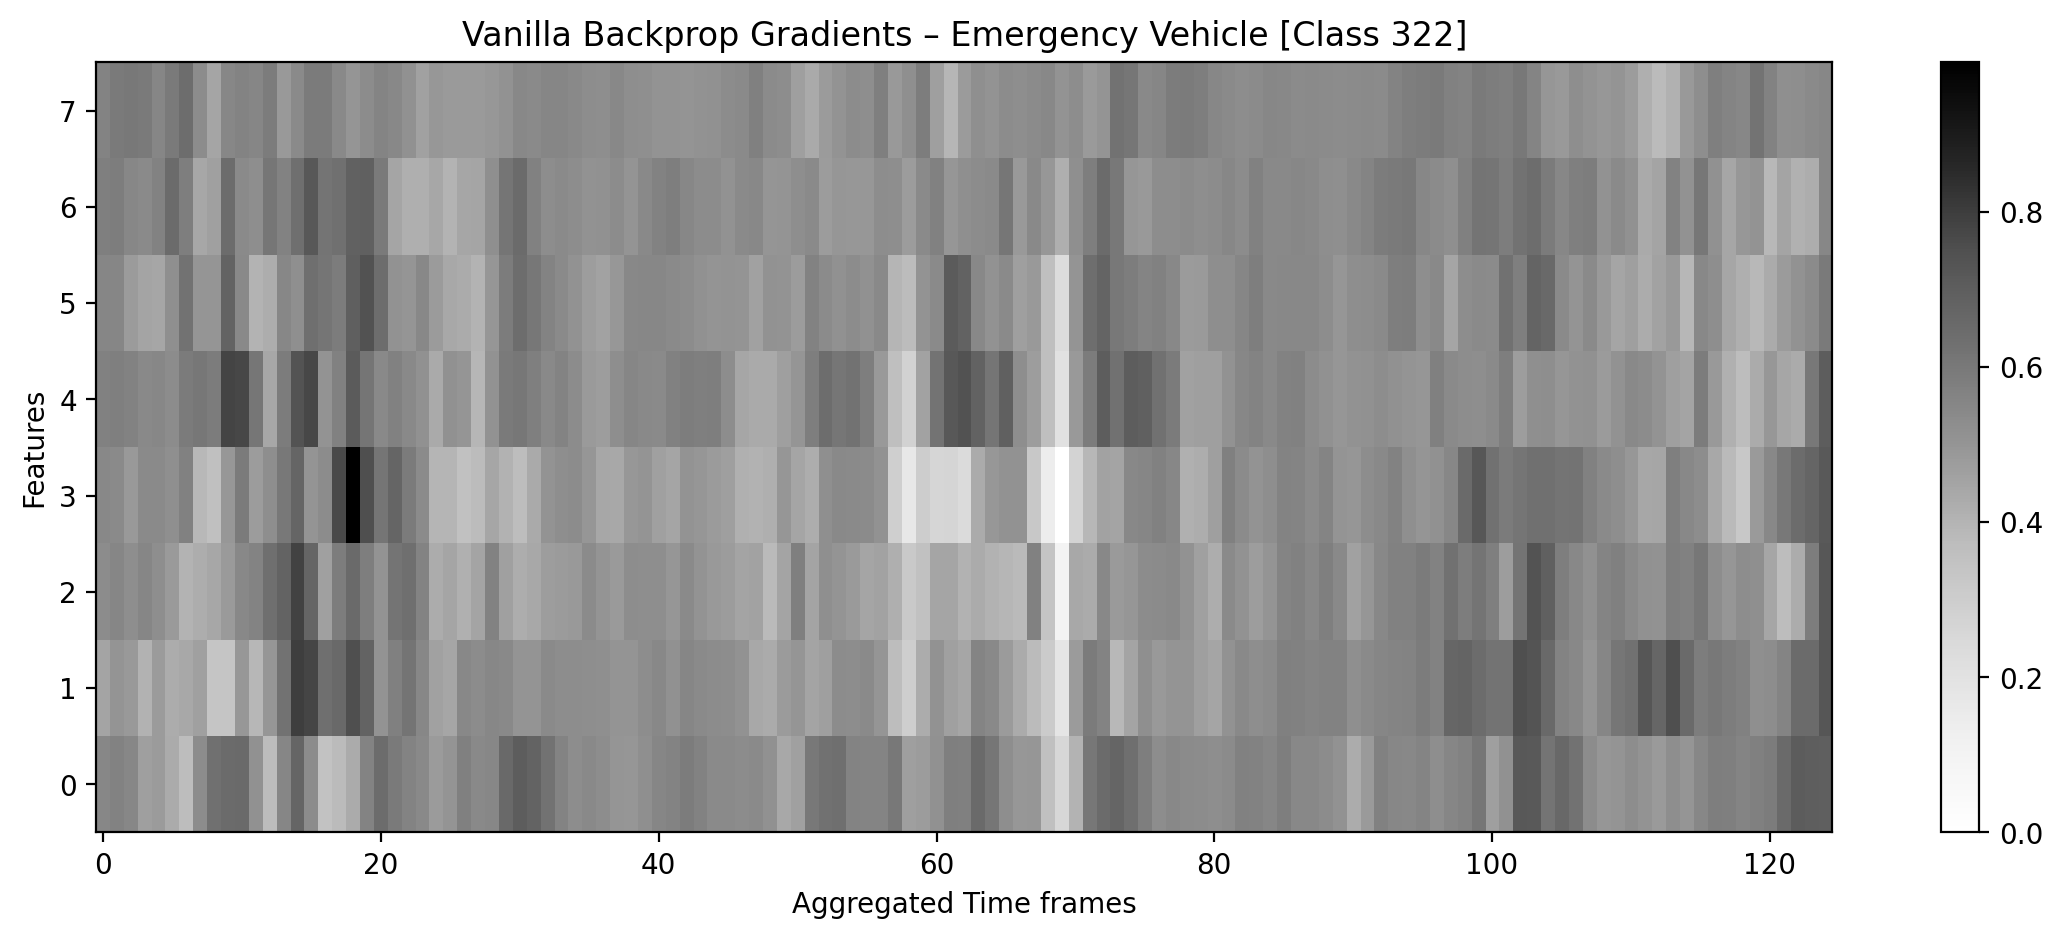

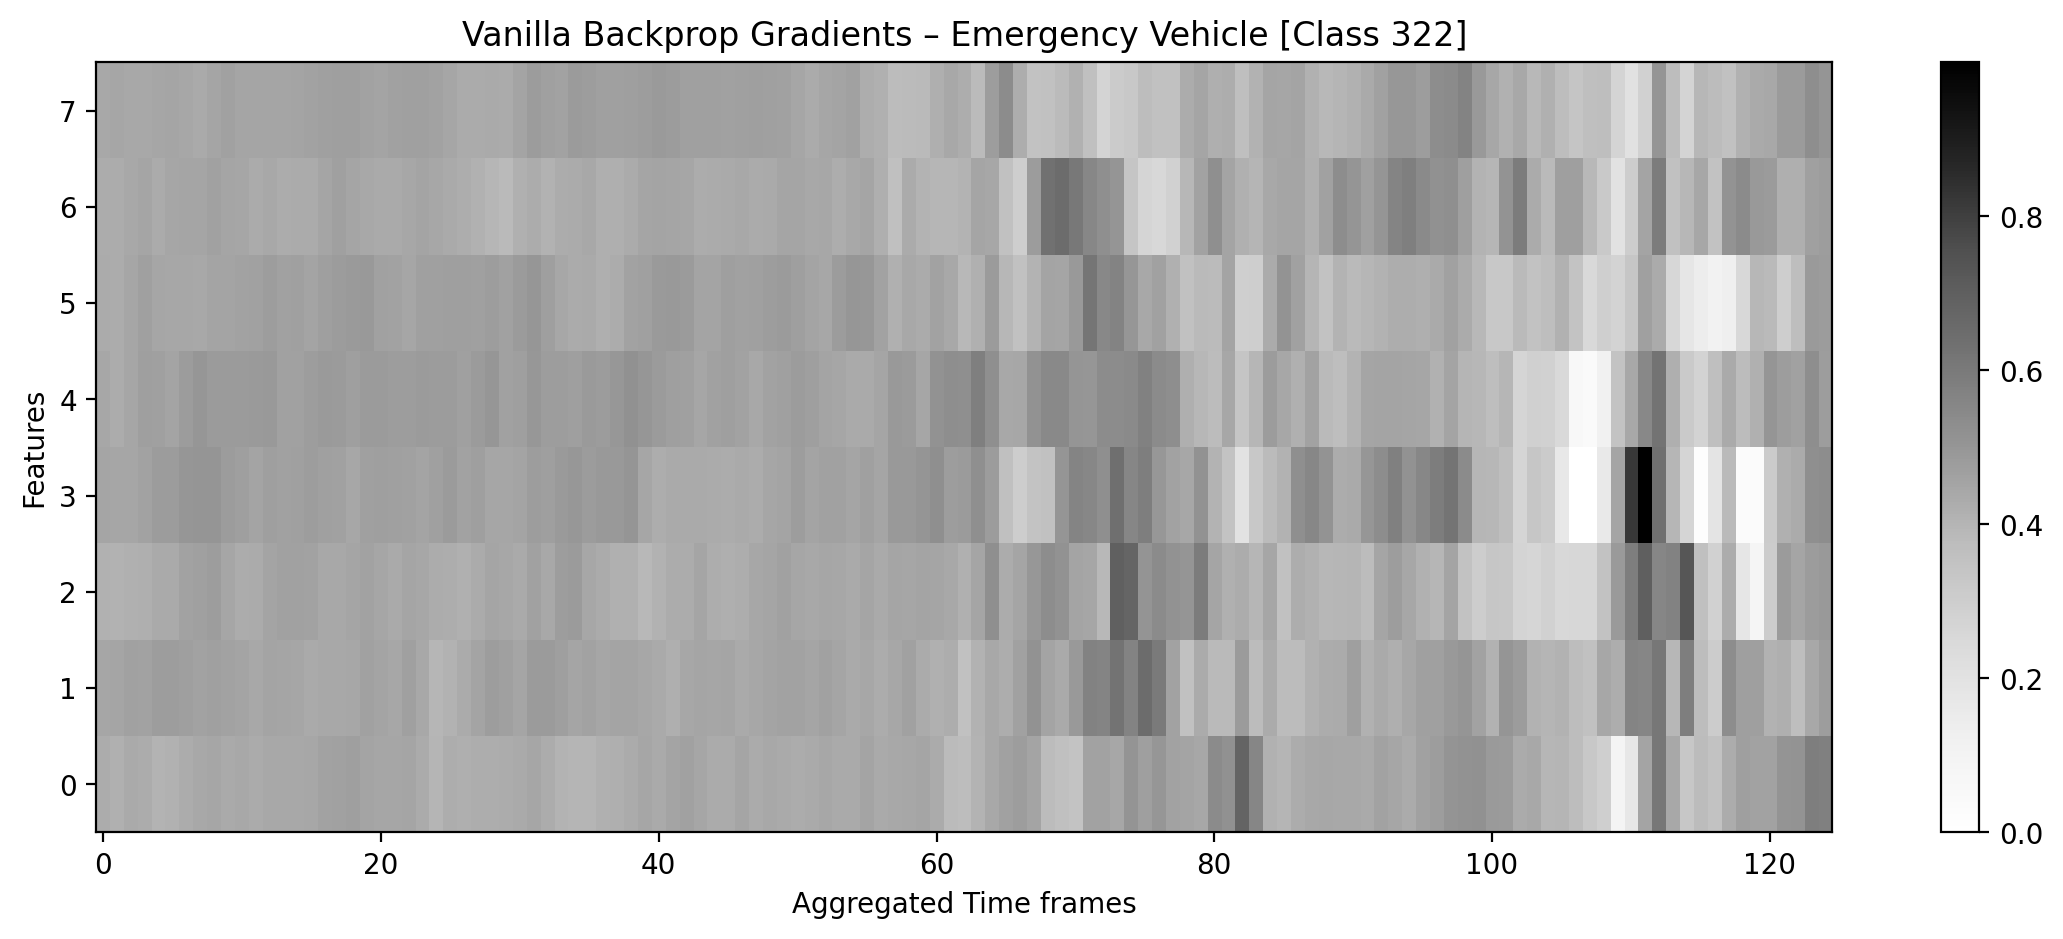

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block3')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

## ConvBlock 4

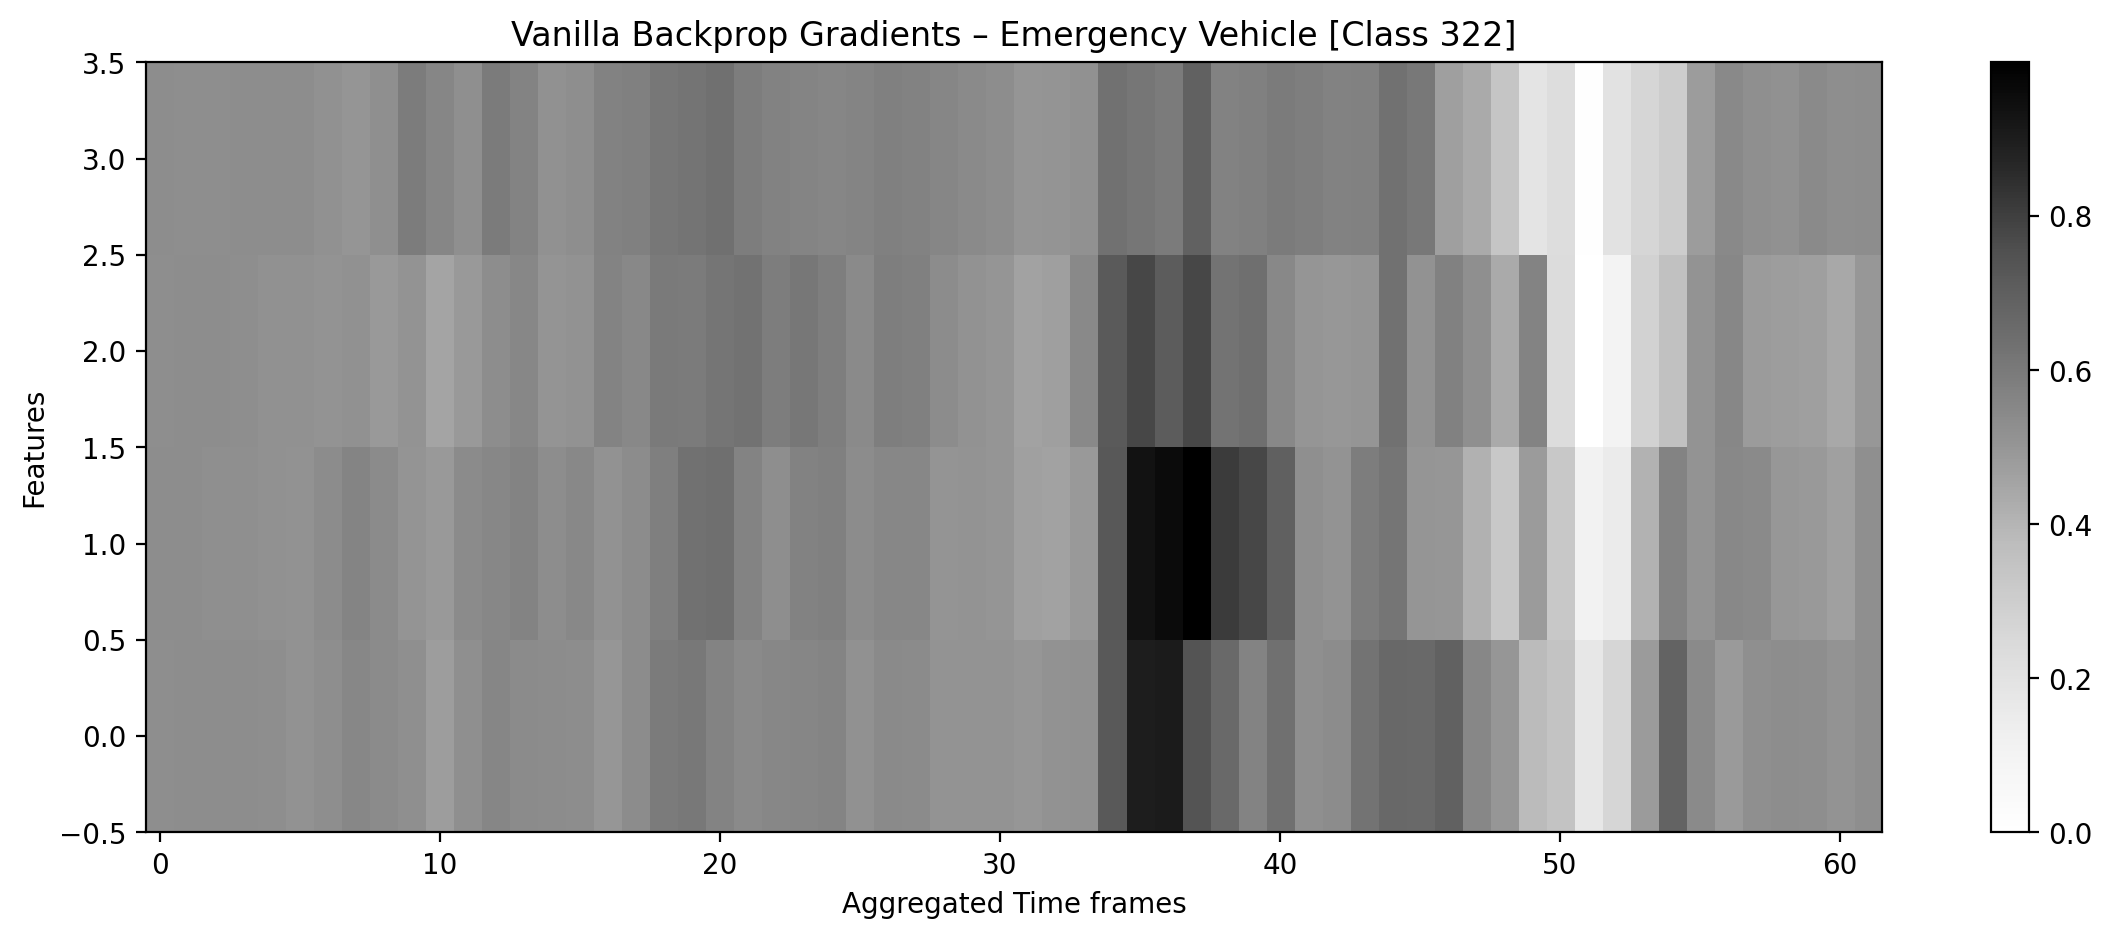

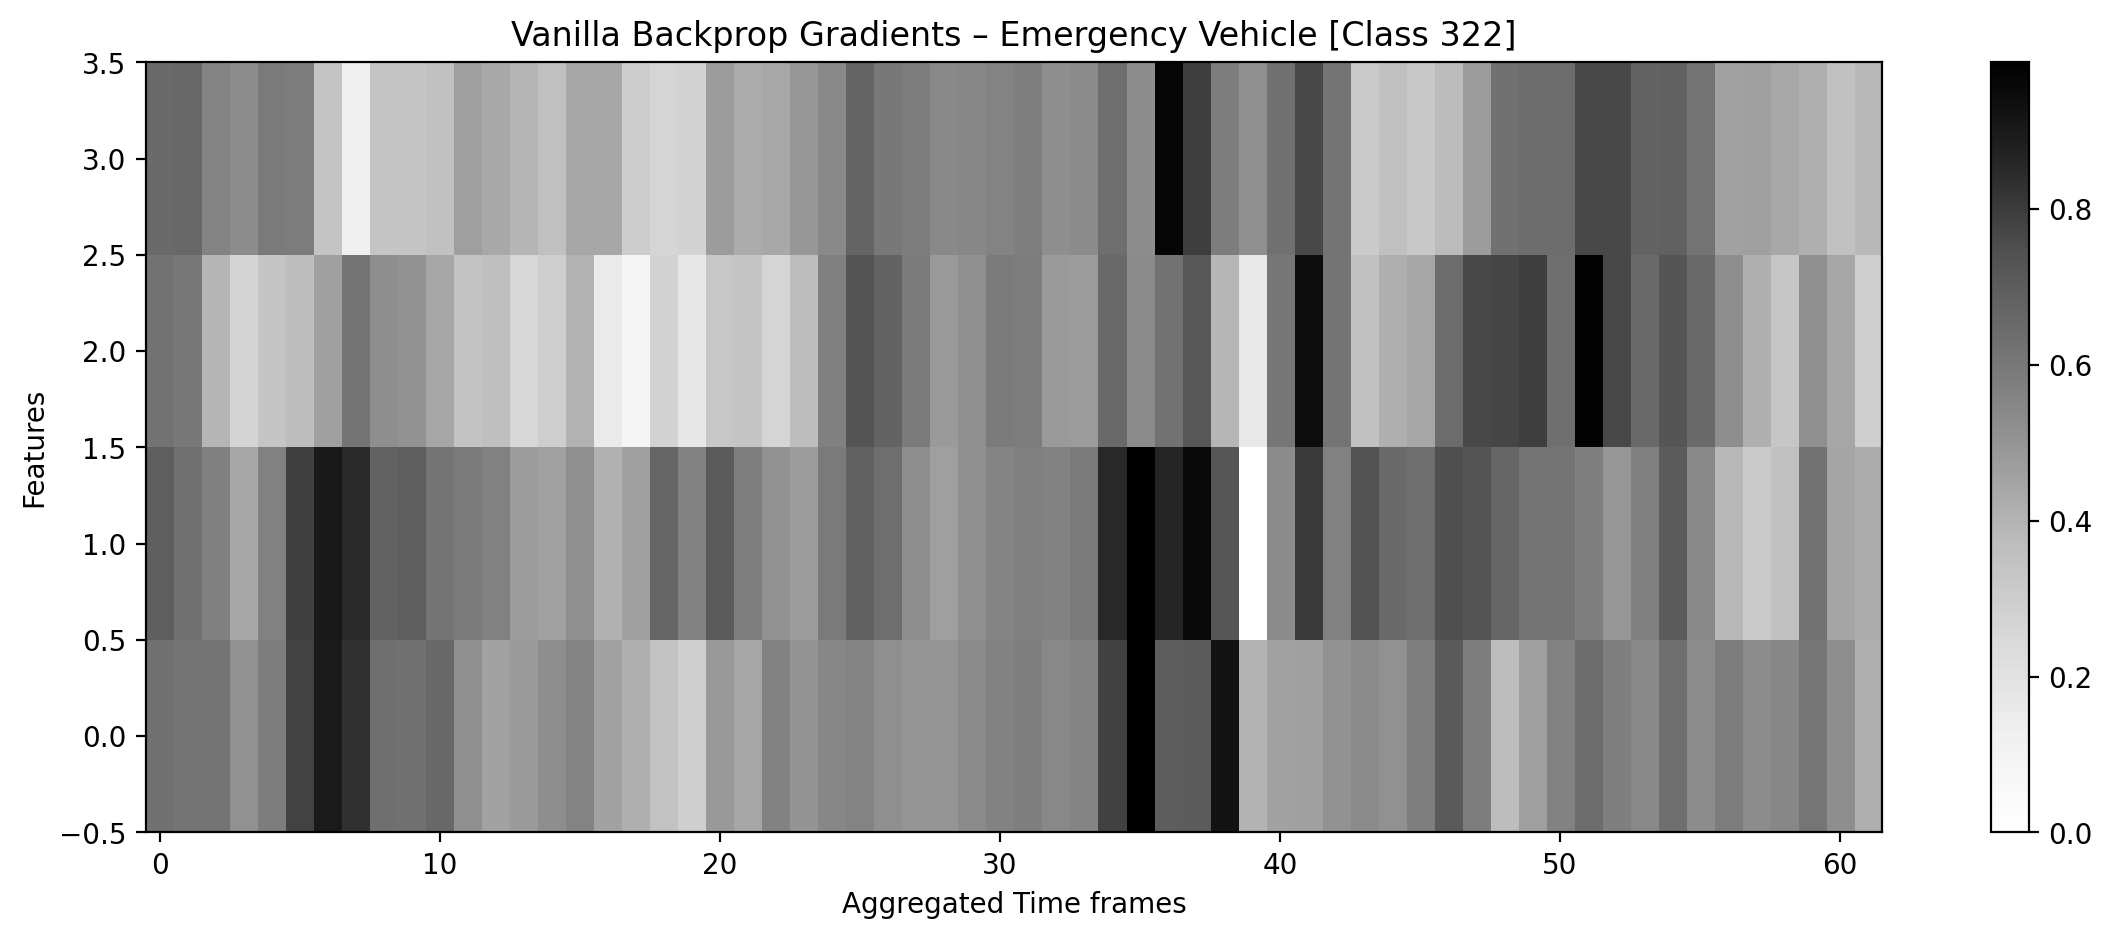

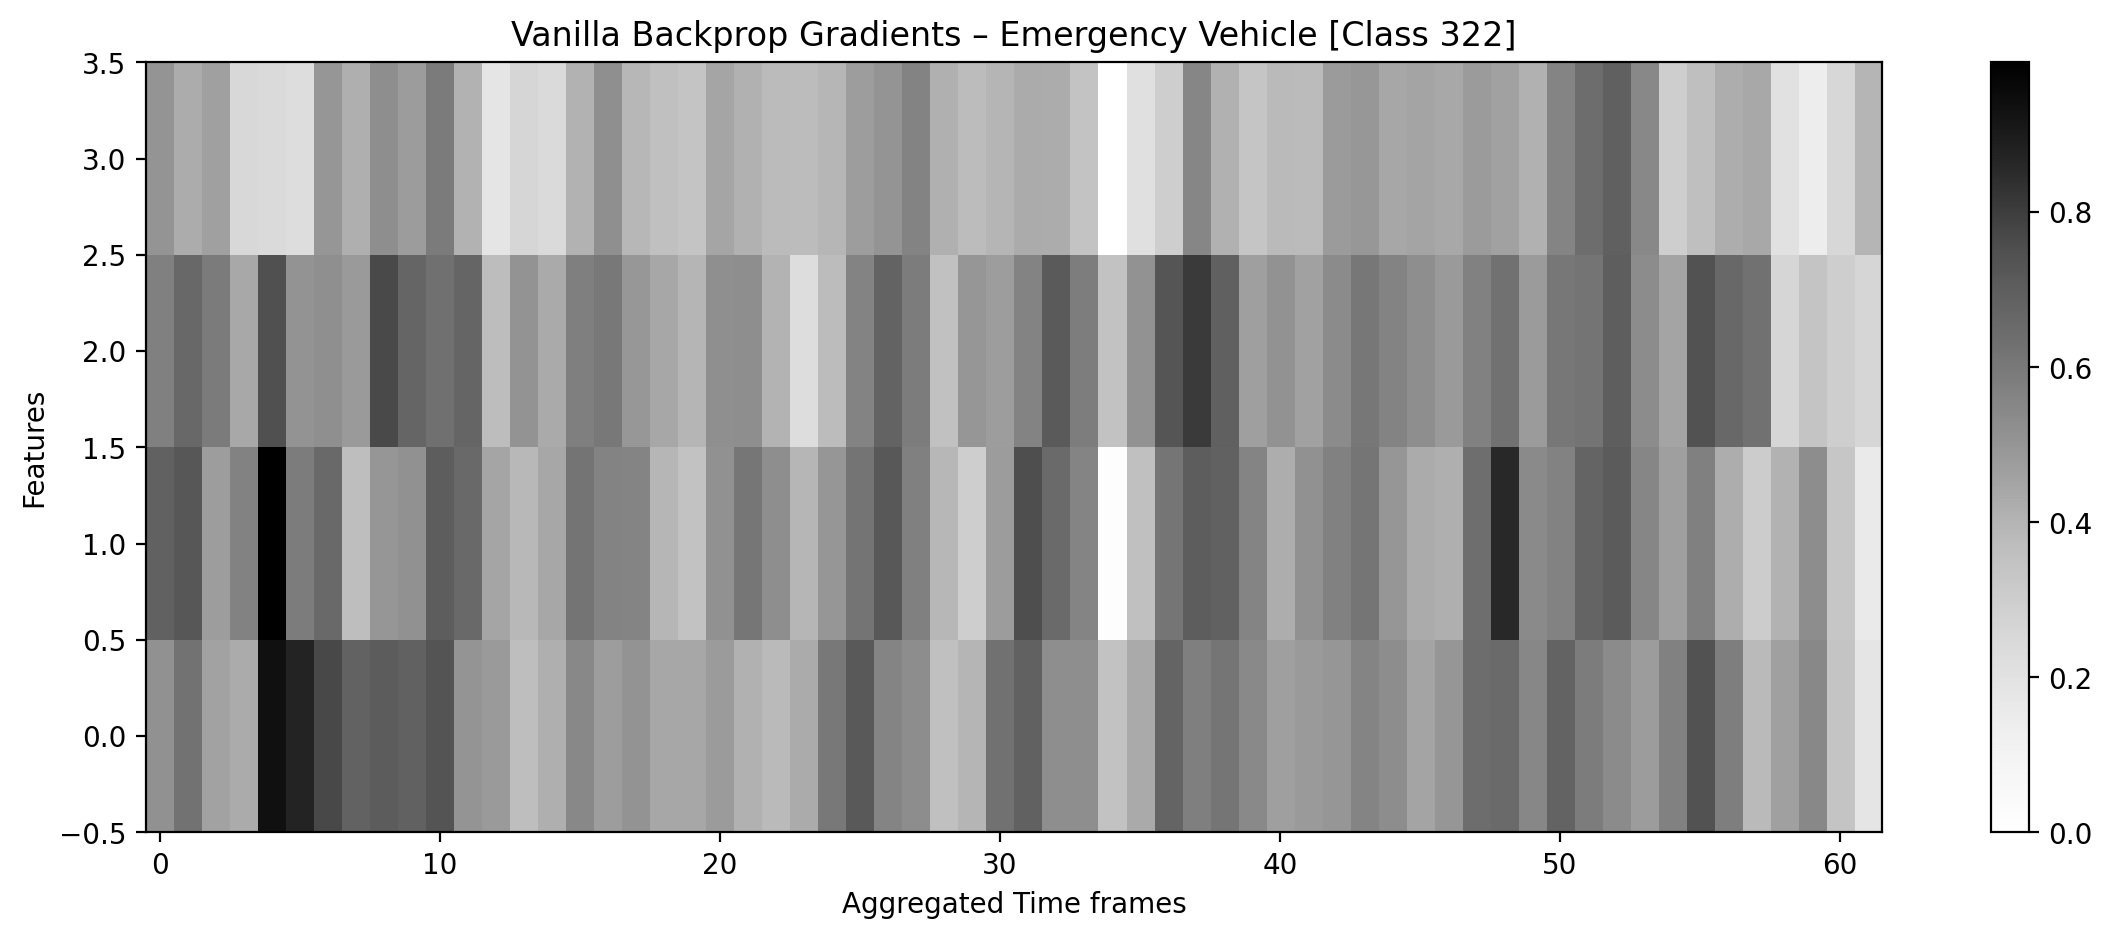

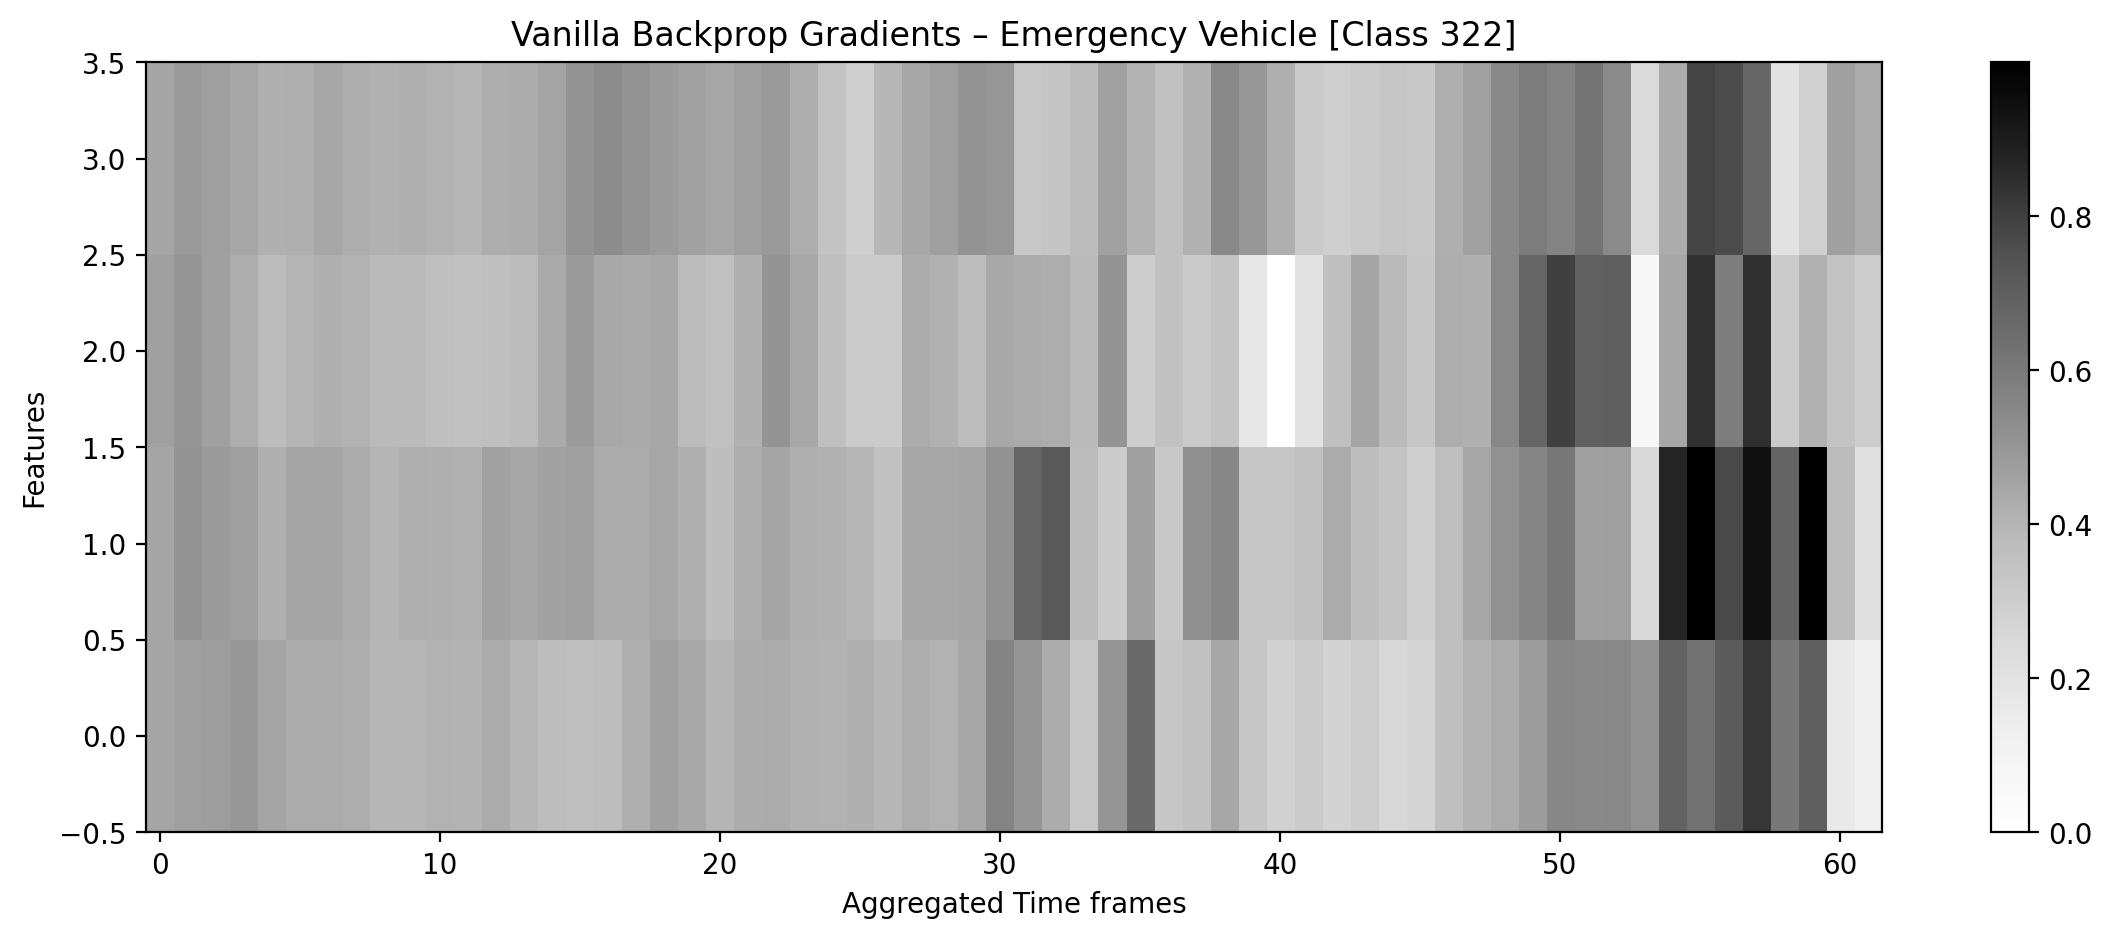

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block4')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

## ConvBlock 5

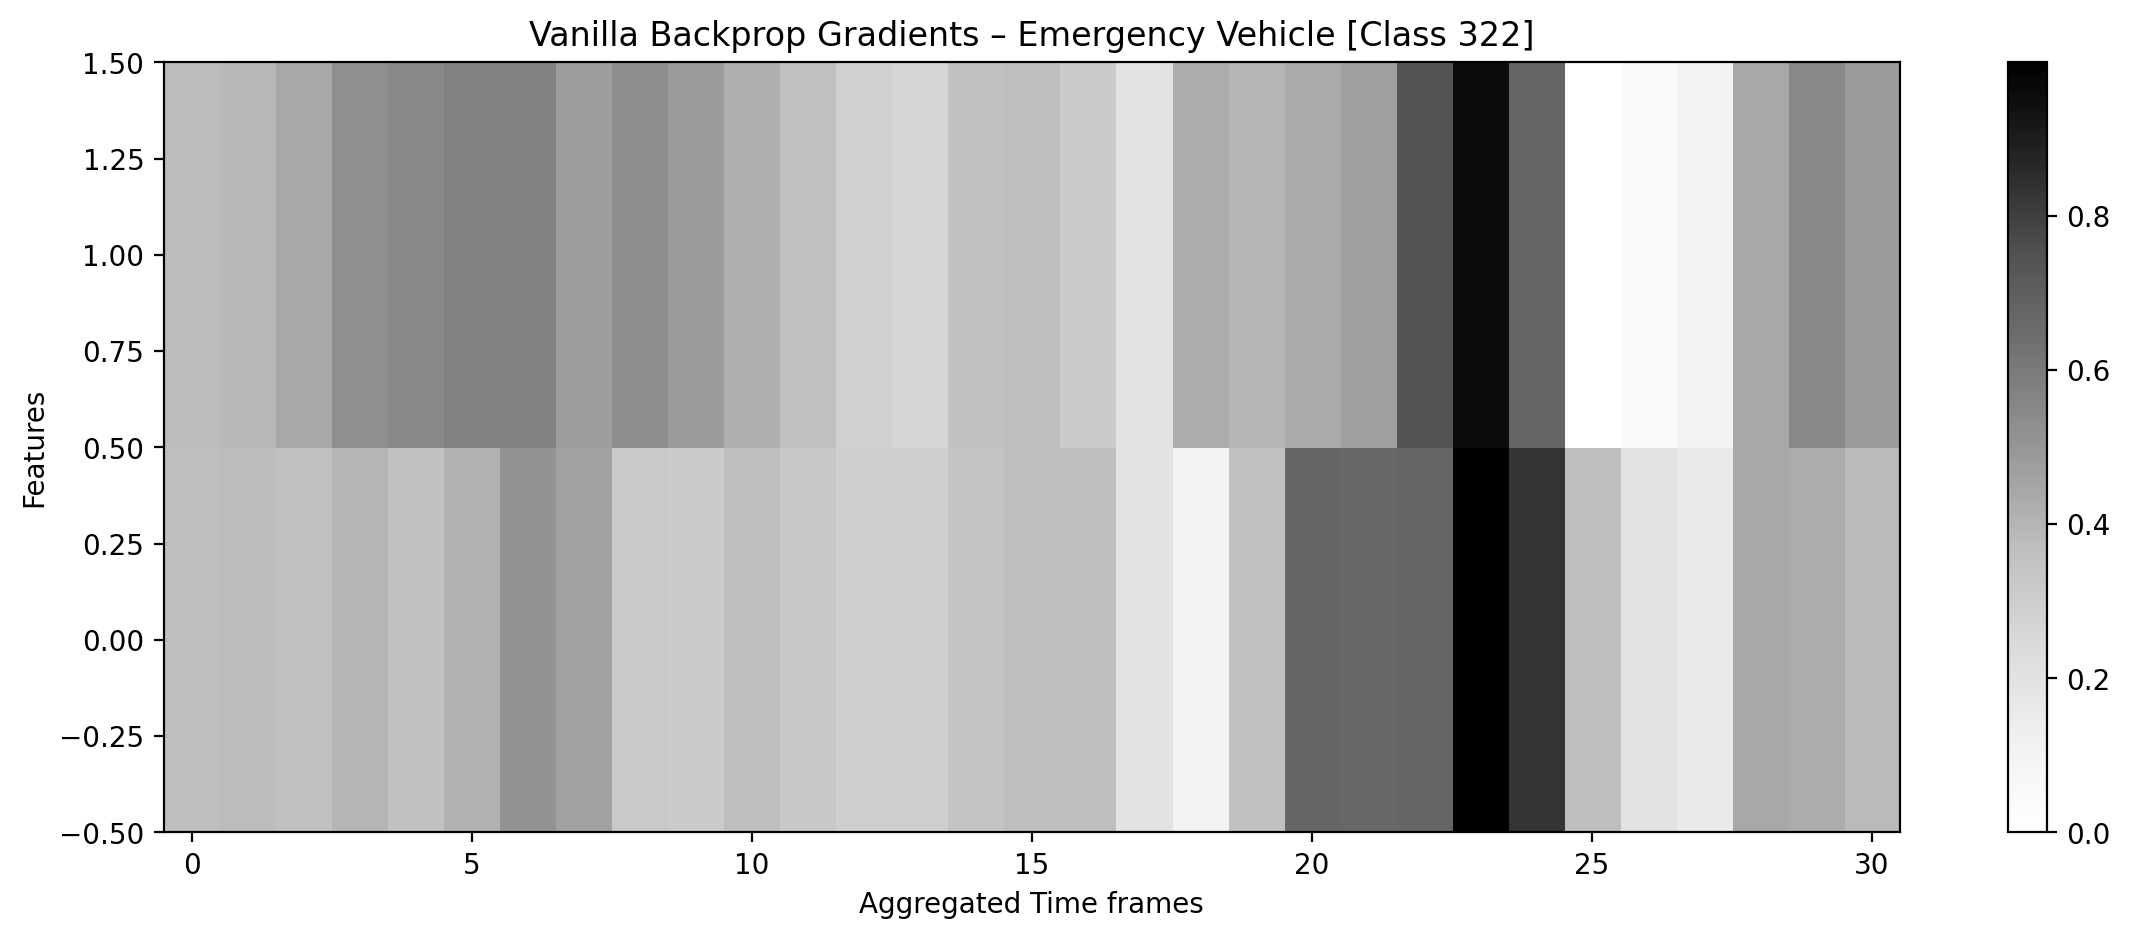

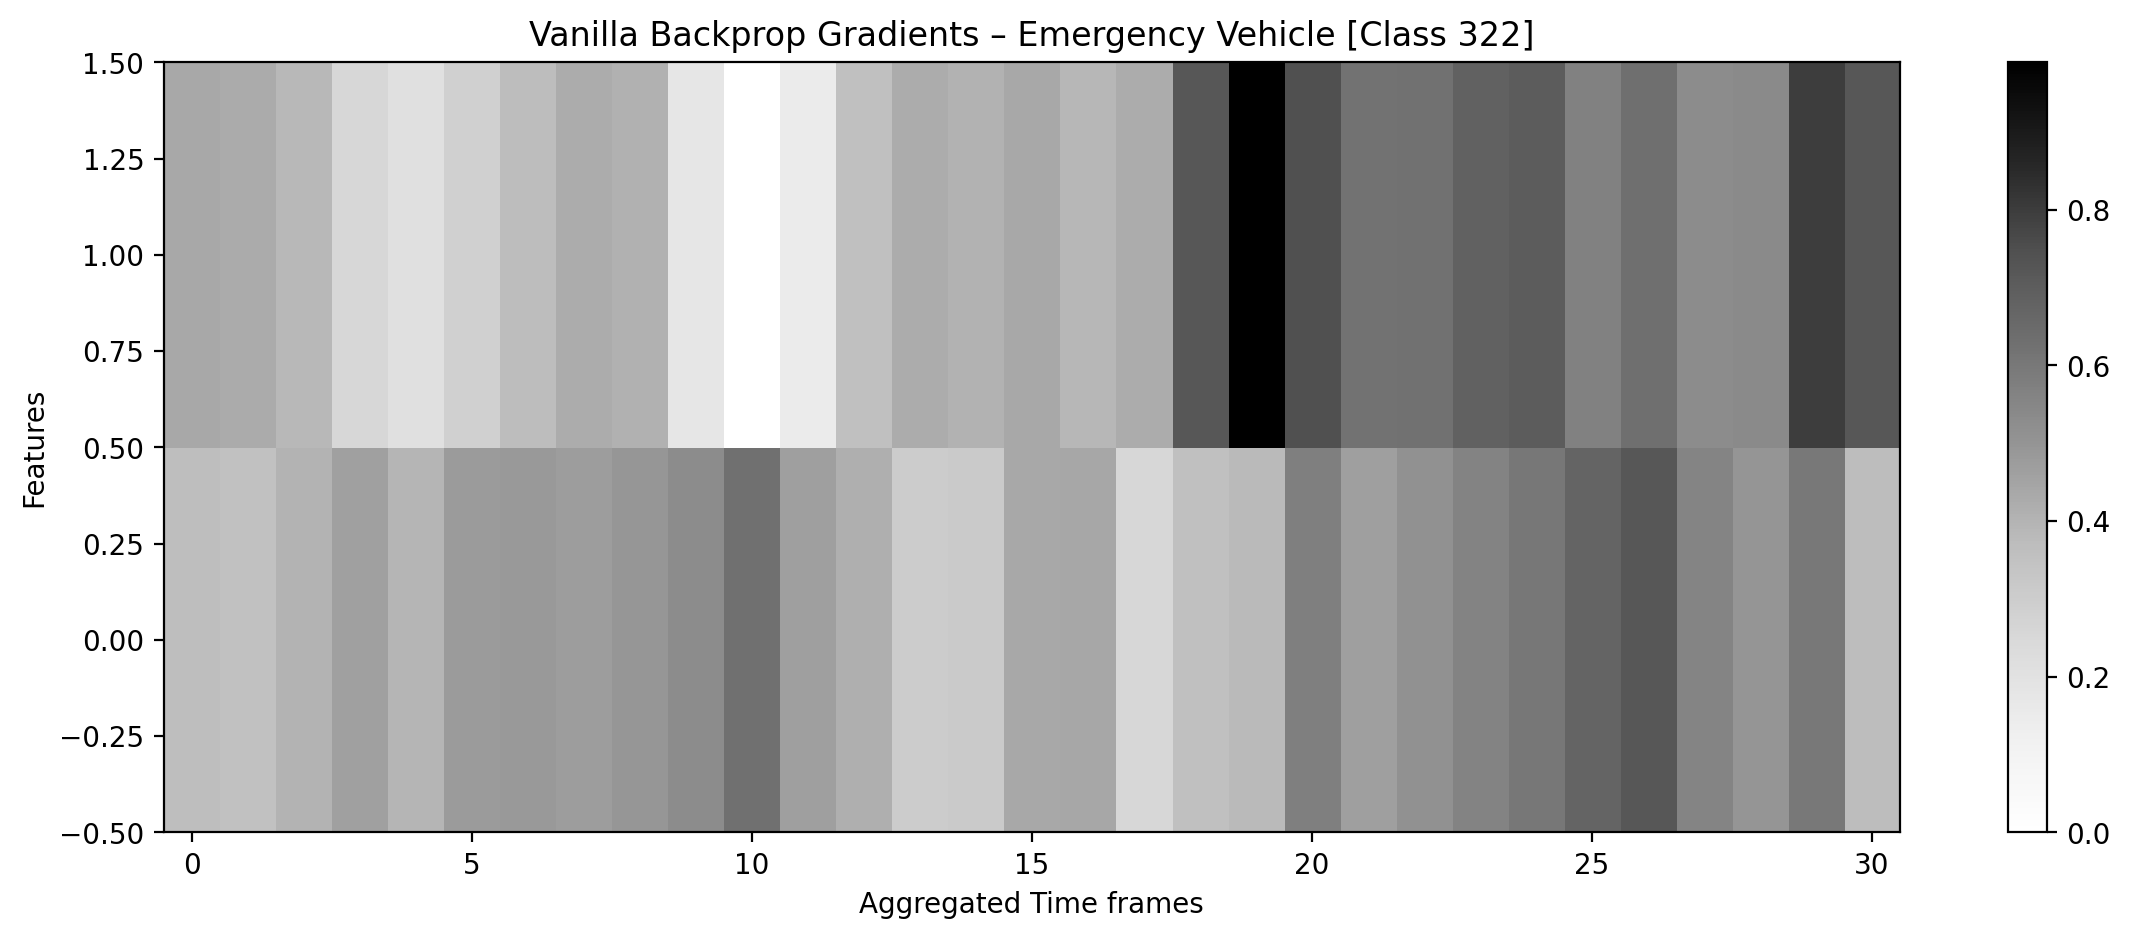

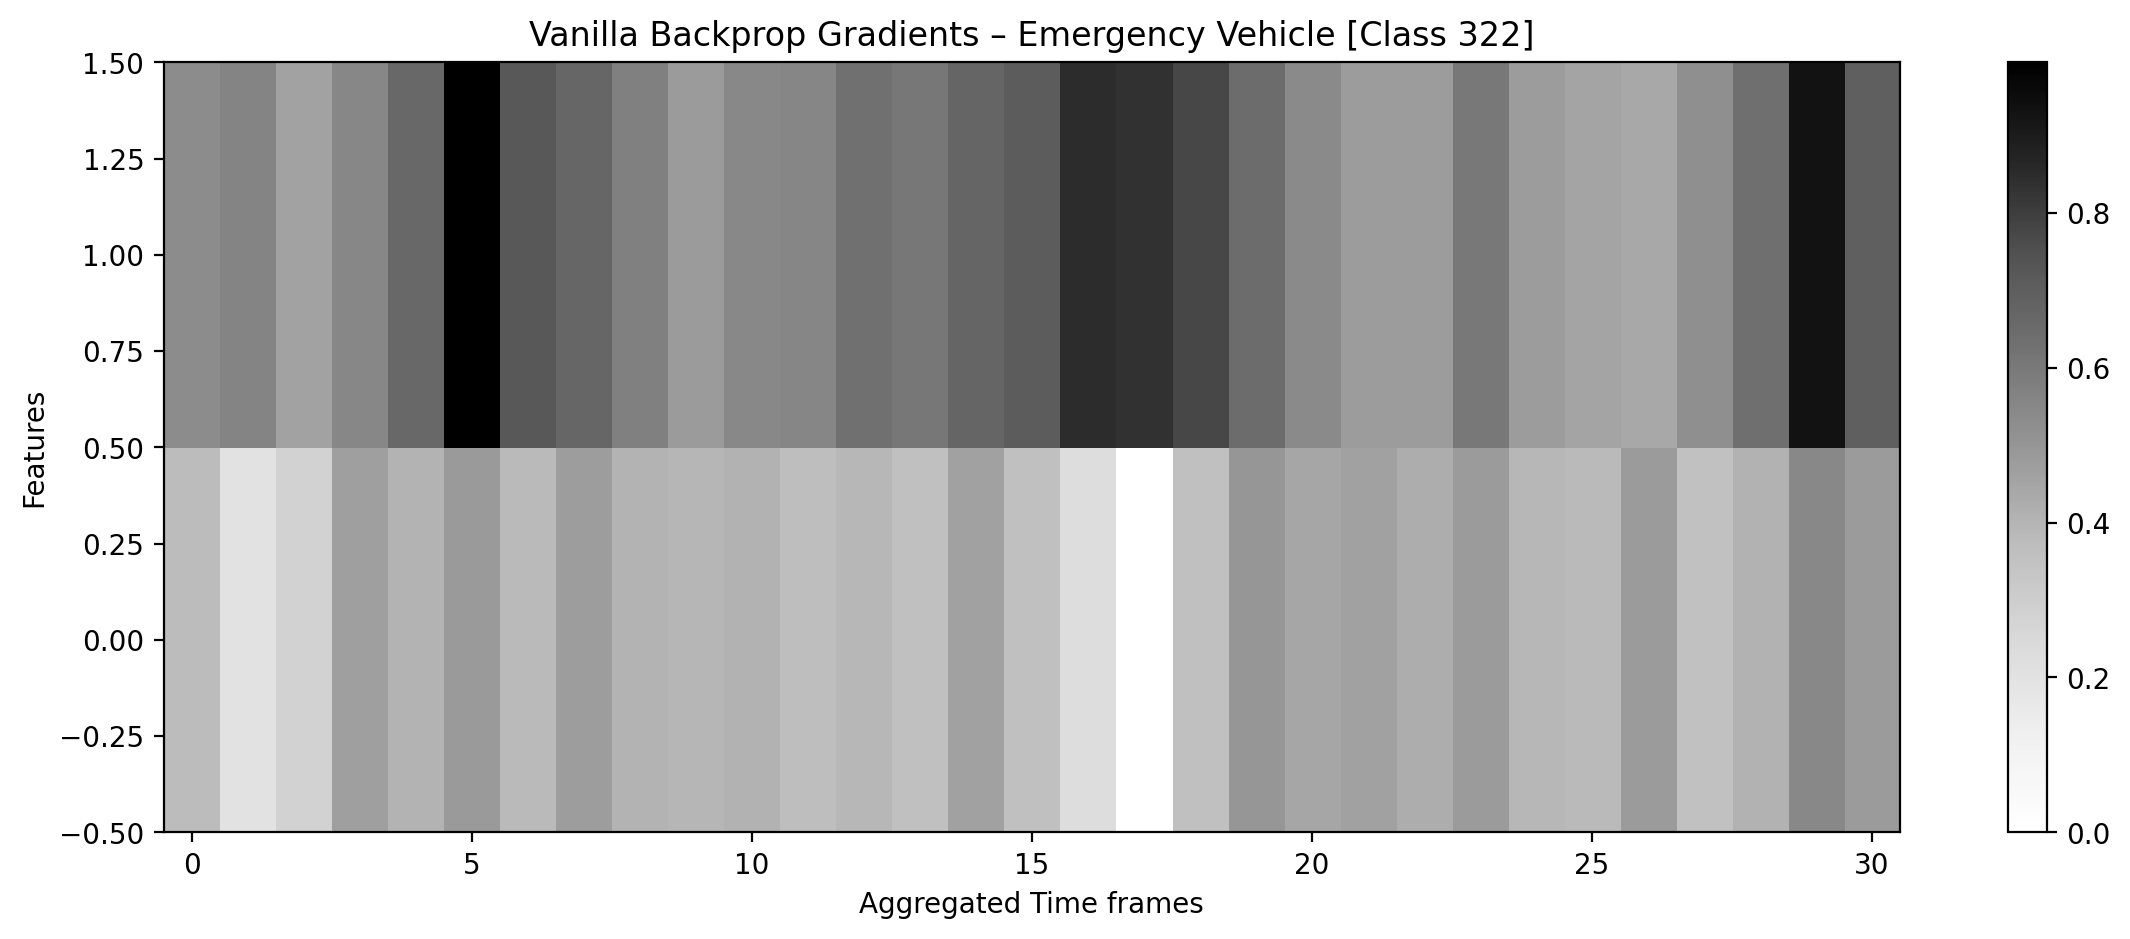

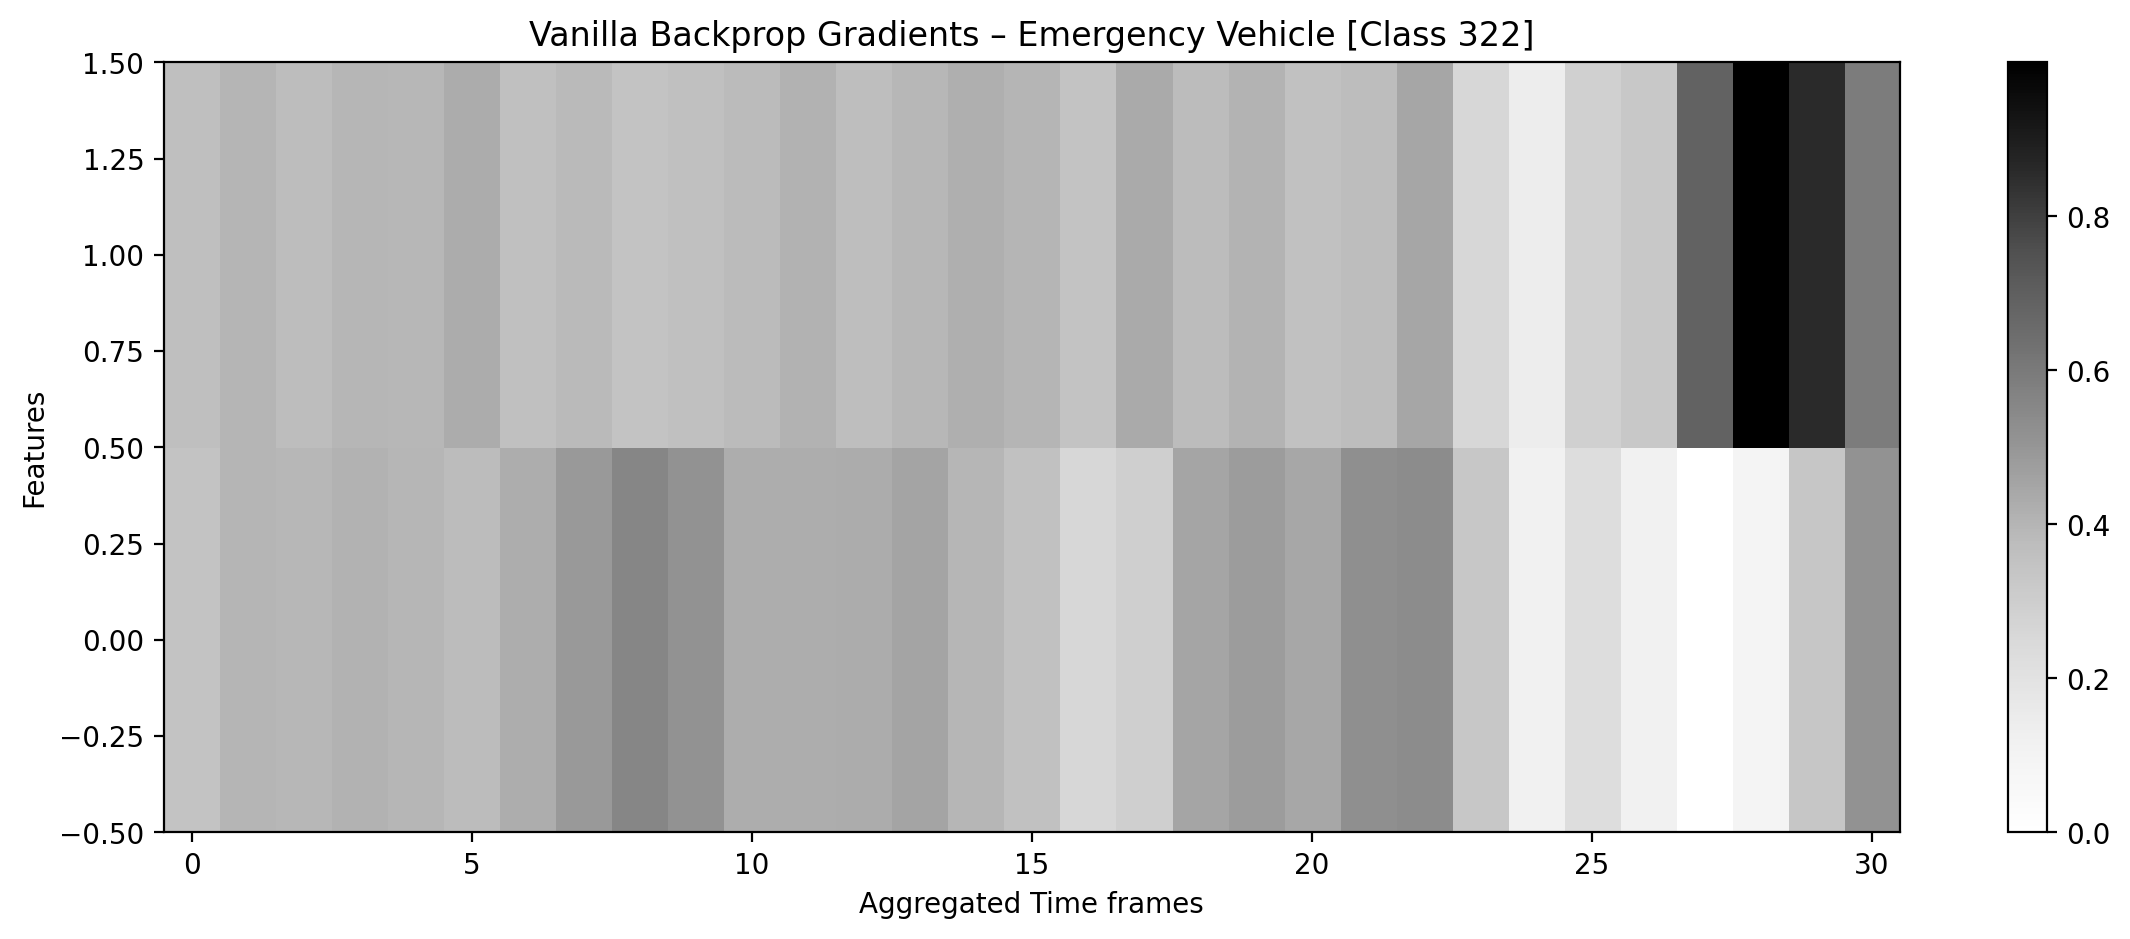

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block5')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

## ConvBlock 6

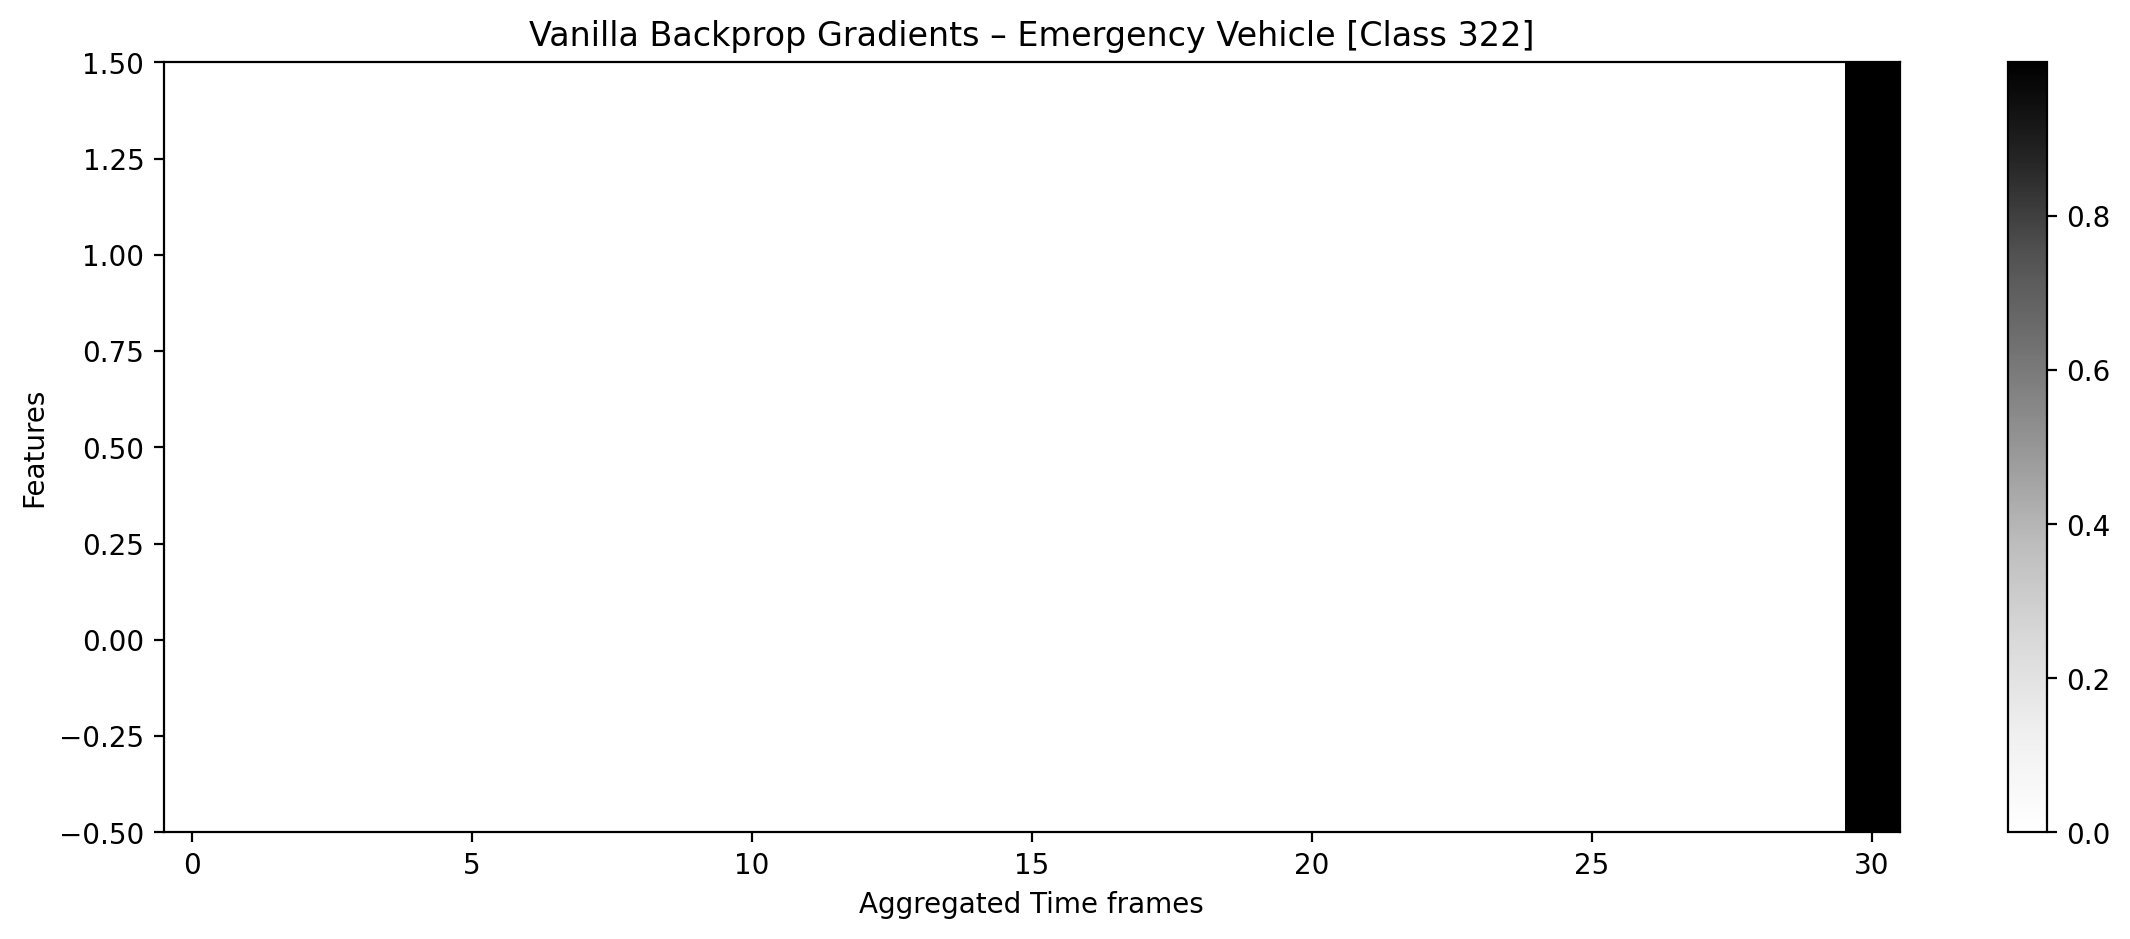

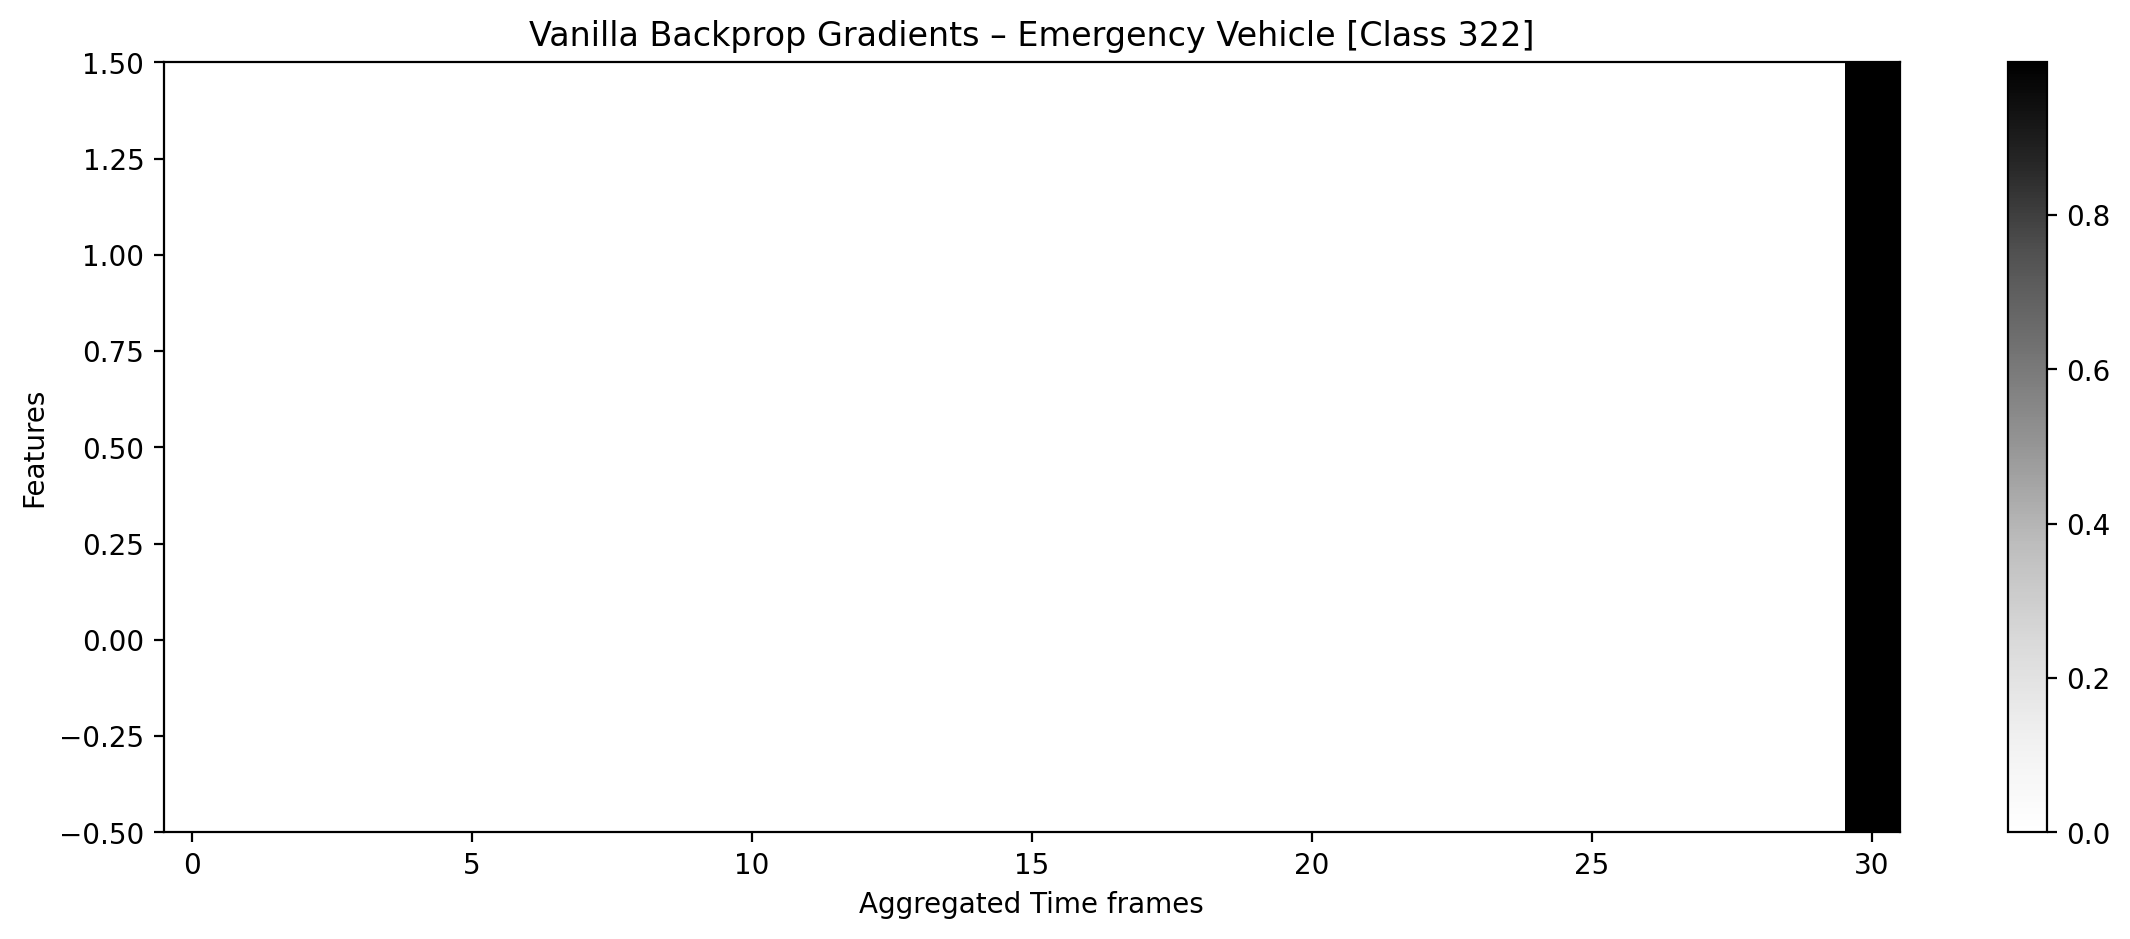

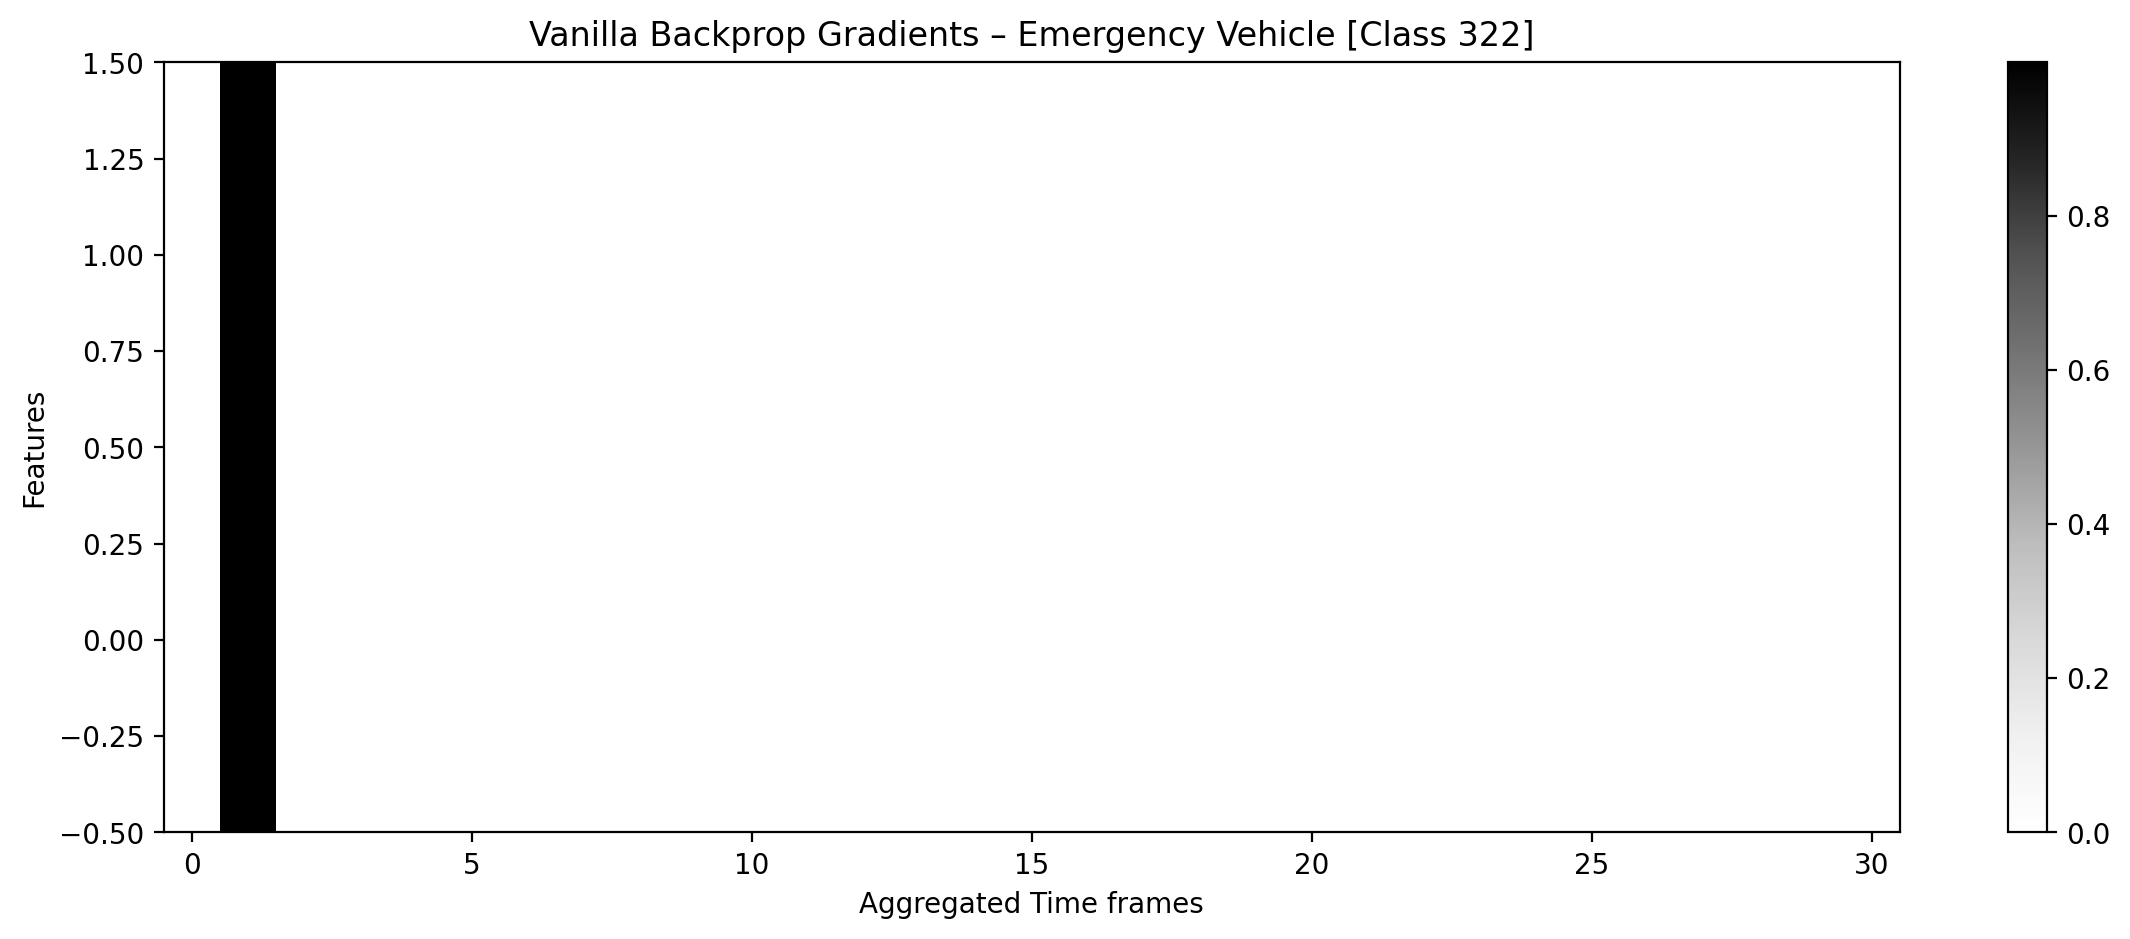

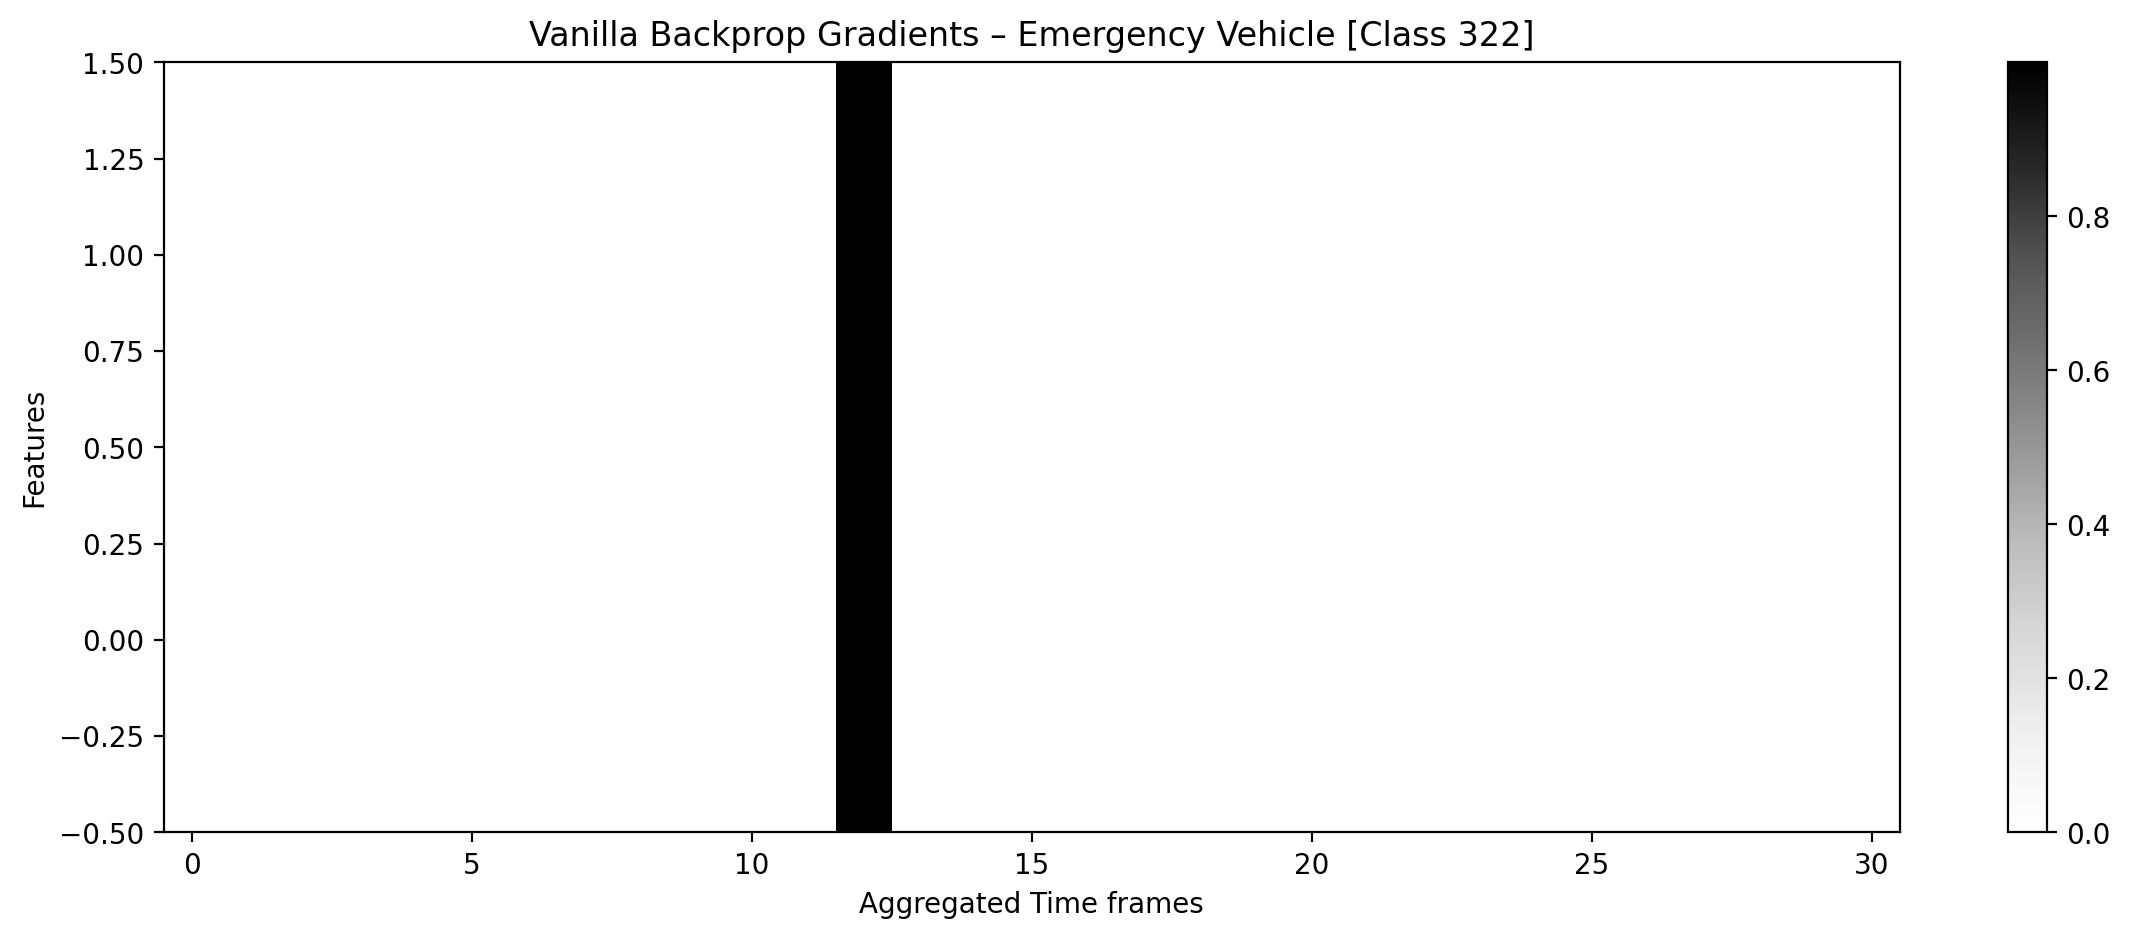

In [ ]:
vbp_ev = VanillaBackprop(model, target_layer='conv_block6')

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[0].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[1].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[2].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

raw_grad, vis_grad = vbp_ev.generate_gradients(audio_data[3].unsqueeze(0))

plt.figure(figsize=(14, 5))
plt.imshow(vis_grad.T, origin='lower', aspect='auto', cmap='Grays')
plt.title('Vanilla Backprop Gradients – Emergency Vehicle [Class 322]')
plt.xlabel('Aggregated Time frames')
plt.ylabel('Features')
plt.colorbar()
plt.show()

# GuidedBackprop

In [ ]:
class GuidedBackprop:
    """
    Guided Backpropagation for CNN-based models.
    Automatically rescales gradient maps and highlights log-mel spectrogram regions.
    """

    def __init__(self, model, target_layer='logmel_extractor', class_index=322):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.forward_relu_outputs = []
        self.target_layer = target_layer
        self.class_index = class_index

        self._hook_target_layer()
        self._hook_relus()

    def _hook_target_layer(self):
        def hook_fn(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        target_module = getattr(self.model, self.target_layer)
        target_module.register_full_backward_hook(hook_fn)

    def _hook_relus(self):
        def relu_forward_hook(module, input_tensor, output_tensor):
            self.forward_relu_outputs.append(output_tensor)

        def relu_backward_hook(module, grad_in, grad_out):
            output = self.forward_relu_outputs.pop()
            mask = (output > 0).float()
            modified_grad = mask * torch.clamp(grad_in[0], min=0.0)
            return (modified_grad,)

        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                module.register_forward_hook(relu_forward_hook)
                module.register_full_backward_hook(relu_backward_hook)

    def generate_gradients(self, waveform):
        """
        Compute raw and normalized gradients with respect to the selected class.
        Also stores the logmel and modulated output for visualization.
        """
        self.forward_relu_outputs = []

        # Extract logmel spectrogram
        with torch.no_grad():
            spec = self.model.spectrogram_extractor(waveform)
            logmel = self.model.logmel_extractor(spec)
            self.logmel_tensor = logmel.squeeze()
            self.logmel_np = self.logmel_tensor.cpu().numpy()
            self.logmel_shape = self.logmel_tensor.shape[-2:]  # (T, F)

        # Normalize logmel between 0 and 1 (robust to -inf)
        logmel_clip = np.clip(self.logmel_np, a_min=-80.0, a_max=None)
        logmel_min = logmel_clip.min()
        logmel_max = np.percentile(logmel_clip, 99)
        self.logmel_norm_np = (logmel_clip - logmel_min) / (logmel_max - logmel_min + 1e-6)

        # Forward + Backward
        output = self.model(waveform.float())['clipwise_output']
        class_score = output[:, self.class_index]
        self.model.zero_grad()
        class_score.sum().backward()

        grad = self.gradients.detach()

        # Average channels if needed
        if grad.shape[1] > 1:
            grad = torch.mean(grad, dim=1, keepdim=True)

        # Resize to match logmel shape
        grad_resized = F.interpolate(grad, size=self.logmel_shape, mode='bilinear', align_corners=False)
        grad_map = grad_resized.squeeze().cpu()

        # Normalize gradient map to [0, 1]
        grad_map -= grad_map.min()
        grad_map /= (grad_map.max() + 1e-6)

        self.grad_map_tensor = grad_map
        self.norm_grad_np = grad_map.numpy()

        # Compute filtered logmel (both normalized between 0-1)
        self.filtered_logmel_np = self.logmel_norm_np * self.norm_grad_np

        return grad_map, self.norm_grad_np

    def plot_overlay(self, title='Guided Backprop Overlay on Log-Mel Spectrogram'):
        """
        Display the gradient map overlaid on the normalized logmel spectrogram.
        """
        plt.figure(figsize=(14, 5))
        plt.imshow(self.logmel_norm_np.T, origin='lower', aspect='auto', cmap='Greys')
        plt.imshow(self.norm_grad_np.T, origin='lower', aspect='auto', cmap='Greys', alpha=0.9)
        plt.colorbar(label='Gradient intensity')
        plt.title(title)
        plt.xlabel('Time frames')
        plt.ylabel('Mel bins')
        plt.tight_layout()
        plt.show()

    def plot_filtered(self, title='Log-Mel Spectrogram Highlighted by Gradients'):
        """
        Plot the log-mel spectrogram filtered by the gradient map.
        """
        plt.figure(figsize=(14, 5))
        plt.imshow(self.filtered_logmel_np.T, origin='lower', aspect='auto', cmap='Greys')
        plt.colorbar(label='Filtered Log-Mel (normalized)')
        plt.title(title)
        plt.xlabel('Time frames')
        plt.ylabel('Mel bins')
        plt.tight_layout()
        plt.show()

## ConvBlock 1

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block1', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 2

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block2', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 3

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block3', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 4

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block4', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 5

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block5', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 6

In [ ]:
gbp_ev = GuidedBackprop(model, target_layer='conv_block6', class_index=322)

for i in range(4):
    raw_grad, norm_grad = gbp_ev.generate_gradients(audio_data[i].unsqueeze(0))
    gbp_ev.plot_overlay(title=f'Guided Backprop Overlay on Log-Mel Spectrogram – Emergency Vehicle [Class 322]')
    gbp_ev.plot_filtered(title=f'Log-Mel Spectrogram Highlighted by Gradients – Emergency Vehicle [Class 322]')
    print()

Output hidden; open in https://colab.research.google.com to view.

# Gradient-weighted Class Activation Map (Grad-CAM)

In [ ]:
class CamExtractor:
    """
    Extracts CAM features and gradients from the model.
    """
    def __init__(self, model, target_layer_name='conv_block6'):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = getattr(self.model, self.target_layer_name)

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

class GradCAM:
    """
    Computes GradCAM heatmaps for audio models.
    """
    def __init__(self, model, target_layer='conv_block6', class_index=322):
        self.model = model
        self.model.eval()
        self.class_index = class_index
        self.extractor = CamExtractor(model, target_layer_name=target_layer)

    def generate_cam(self, waveform):
        # Forward
        output = self.model(waveform.float())['clipwise_output']
        class_score = output[:, self.class_index]
        self.model.zero_grad()
        class_score.sum().backward()

        gradients = self.extractor.gradients  # (1, C, T, F)
        activations = self.extractor.activations  # (1, C, T, F)

        if gradients is None or activations is None:
            raise RuntimeError("Hooks did not capture activations or gradients.")

        # Global average pooling
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)  # shape: (1, C, 1, 1)

        # Weighted sum
        cam = torch.sum(weights * activations, dim=1).squeeze(0)  # shape: (T, F)
        cam = F.relu(cam)

        # Normalize to 0–1
        cam -= cam.min()
        cam /= (cam.max() + 1e-6)

        return cam.cpu().numpy()

def plot_cam_on_logmel(model, waveform, cam_map, title='GradCAM Overlay on Log-Mel Spectrogram', cmap='Greys'):
    """
    Plots GradCAM heatmap over log-mel spectrogram extracted from the model.
    """
    with torch.no_grad():
        spec = model.spectrogram_extractor(waveform)
        logmel = model.logmel_extractor(spec).squeeze().cpu().numpy()

    # Normalize logmel to [0, 1] assuming dB range [-80, 0]
    logmel_norm = np.clip((logmel + 80) / 80, 0, 1)

    # Resize CAM to match logmel size
    cam_resized = F.interpolate(torch.tensor(cam_map).unsqueeze(0).unsqueeze(0),
                                size=logmel.shape,
                                mode='bilinear',
                                align_corners=False).squeeze().numpy()

    # Overlay
    plt.figure(figsize=(14, 5))
    plt.imshow(logmel_norm.T, origin='lower', aspect='auto', cmap='Greys')
    plt.imshow(cam_resized.T, origin='lower', aspect='auto', cmap=cmap, alpha=0.7)
    plt.title(title)
    plt.xlabel('Time frames')
    plt.ylabel('Mel bins')
    plt.colorbar(label='CAM intensity')
    plt.tight_layout()
    plt.show()

## Audio 1

In [ ]:
gc = GradCAM(model, target_layer='conv_block1', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block2', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block3', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block4', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block5', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block6', class_index=322)
cam = gc.generate_cam(audio_data[0].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[0].unsqueeze(0), cam)

Output hidden; open in https://colab.research.google.com to view.

## Audio 2

In [ ]:
gc = GradCAM(model, target_layer='conv_block1', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block2', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block3', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block4', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block5', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block6', class_index=322)
cam = gc.generate_cam(audio_data[1].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[1].unsqueeze(0), cam)

Output hidden; open in https://colab.research.google.com to view.

## Audio 3

In [ ]:
gc = GradCAM(model, target_layer='conv_block1', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block2', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block3', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block4', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block5', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block6', class_index=322)
cam = gc.generate_cam(audio_data[2].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[2].unsqueeze(0), cam)

Output hidden; open in https://colab.research.google.com to view.

## Audio 4

In [ ]:
gc = GradCAM(model, target_layer='conv_block1', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block2', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block3', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block4', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block5', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

gc = GradCAM(model, target_layer='conv_block6', class_index=322)
cam = gc.generate_cam(audio_data[3].unsqueeze(0))
plot_cam_on_logmel(model, audio_data[3].unsqueeze(0), cam)

Output hidden; open in https://colab.research.google.com to view.

# Score Class Activation Map (Score-CAM)

In [ ]:
class ScoreCAM:
    """
    Score-CAM for CNN-based audio models using log-mel spectrograms.
    """
    def __init__(self, model, target_layer='conv_block6', class_index=322):
        self.model = model
        self.model.eval()
        self.class_index = class_index
        self.extractor = CamExtractor(self.model, target_layer_name=target_layer)

    def generate_cam(self, waveform):
        with torch.no_grad():
            # Extract logmel for shape and later overlay
            spec = self.model.spectrogram_extractor(waveform)
            logmel = self.model.logmel_extractor(spec)
            self.logmel_tensor = logmel.squeeze(0).squeeze(0)  # shape (T, F)
            self.logmel_np = self.logmel_tensor.cpu().numpy()
            self.logmel_shape = self.logmel_tensor.shape  # (T, F)

        # Run model forward to trigger hook and get output score
        output = self.model(waveform)['clipwise_output']
        score = output[0, self.class_index].item()

        # Extract activations from hook
        activations = self.extractor.activations.detach().squeeze(0)  # shape (C, t, f)
        cam = np.zeros(self.logmel_shape, dtype=np.float32)

        for i in range(activations.shape[0]):
            act = activations[i:i+1].unsqueeze(0)  # shape (1, 1, t, f)
            upsampled = F.interpolate(act, size=self.logmel_shape, mode='bilinear', align_corners=False)
            norm_map = upsampled.squeeze()

            if norm_map.max() == norm_map.min():
                continue

            norm_map = (norm_map - norm_map.min()) / (norm_map.max() - norm_map.min() + 1e-6)
            masked_logmel = self.logmel_tensor * norm_map
            masked_logmel_input = masked_logmel.unsqueeze(0).unsqueeze(0)  # shape (1, 1, T, F)

            with torch.no_grad():
                masked_output = self.model(waveform)['clipwise_output']
                weight = masked_output[0, self.class_index].item()

            cam += weight * norm_map.cpu().numpy()

        # Normalize CAM between 0 and 1
        cam = np.maximum(cam, 0)
        cam -= cam.min()
        cam /= (cam.max() + 1e-6)
        self.cam_np = cam

        return self.cam_np

    def plot_overlay(self, title='ScoreCAM Overlay on Log-Mel Spectrogram'):
        plt.figure(figsize=(14, 5))
        plt.imshow(self.logmel_np.T, origin='lower', aspect='auto', cmap='Greys')
        plt.imshow(self.cam_np.T, origin='lower', aspect='auto', cmap='Greys', alpha=0.9)
        plt.colorbar(label='ScoreCAM intensity')
        plt.title(title)
        plt.xlabel('Time frames')
        plt.ylabel('Mel bins')
        plt.tight_layout()
        plt.show()

## ConvBlock 1

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block1', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 2

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block2', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 3

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block3', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 4

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block4', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 5

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block5', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.

## ConvBlock 6

In [ ]:
for i in range (audio_data.shape[0]):
    scam_ev = ScoreCAM(model, target_layer='conv_block6', class_index=322)
    cam_map = scam_ev.generate_cam(audio_data[i].unsqueeze(0))
    scam_ev.plot_overlay(title='ScoreCAM Overlay – Emergency Vehicle [Class 322]')

Output hidden; open in https://colab.research.google.com to view.